# IMPORT PACKAGES

In [316]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import fdrcorrection
import matplotlib_venn
# from venny4py.venny4py import *
from scipy import stats
import math
from matplotlib.lines import Line2D
from matplotlib.text import Text
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler
# import lightgbm as lgb
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pickle
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import matplotlib
import random
import unicodeit
from matplotlib.colors import LinearSegmentedColormap
import umap
from sklearn.manifold import TSNE

In [317]:
from scipy.stats import entropy

# DEFINE FUNCTION

In [318]:
#Hàm wilcoxon mới
def STATS_binary(df_1,df_2,col_start,name_1,name_2,groups_PADJ=[]):
    # import pandas as pd
    # import numpy as np
    # from statsmodels.stats.multitest import fdrcorrection
    # from scipy import stats
    # import math
    Mean_1,Mean_2,Median_1,Median_2,Feature,P_value,AUC,Log2FC, Log2FC_Median=[],[],[],[],[],[],[],[],[]
    SD_1,SD_2,CVpct_1,CVpct_2=[],[],[],[]
    for i in range(col_start,df_1.shape[1]):
        #Mean
        m1=np.mean(list(df_1.iloc[:,i]))
        m2=np.mean(list(df_2.iloc[:,i]))
        Mean_1+=[m1]
        Mean_2+=[m2]
        #Median
        me1=np.median(list(df_1.iloc[:,i]))
        me2=np.median(list(df_2.iloc[:,i]))
        Median_1+=[me1]
        Median_2+=[me2]
        #P-value
        P_value+=[stats.ranksums(df_1.iloc[:,i],df_2.iloc[:,i])[1]]
        #Log2FC
        if m1 !=0 and m2 !=0:
            Log2FC+=[math.log2(abs(m2/m1))]
        else:
            Log2FC+=[0]

        if me1 !=0 and me2 !=0:
            Log2FC_Median+=[math.log2(abs(me2/me1))]
        else:
            Log2FC_Median+=[0]
        #Features
        Feature+=[df_1.columns[i]]
        #AUC
        AUC+=[metrics.roc_auc_score([0]*len(df_1)+[1]*len(df_2), list(df_1.iloc[:,i])+list(df_2.iloc[:,i]))]
        #SD and CV%
        sd1=np.std(list(df_1.iloc[:,i]))
        sd2=np.std(list(df_2.iloc[:,i]))
        SD_1+=[sd1]
        SD_2+=[sd2]
        if m1 != 0:
            CVpct_1+=[sd1/m1*100]
        else: 
            CVpct_1+=[np.nan]
        if m2 != 0:
            CVpct_2+=[sd2/m2*100]
        else: 
            CVpct_2+=[np.nan]
    else:
        result=pd.DataFrame({'FEATURES':Feature,
                             'Mean of '+name_1:Mean_1,
                             'Mean of '+name_2:Mean_2,
                             'Median of '+name_1:Median_1,
                             'Median of '+name_2:Median_2,
                             'SD of '+name_1:SD_1,
                             'SD of '+name_2:SD_2,
                             'CV% of '+name_1:CVpct_1,
                             'CV% of '+name_2:CVpct_2,
                             'Log2FC of '+name_1+' vs '+name_2:Log2FC,
                             'Log2FC Median of '+name_1+' vs '+name_2:Log2FC_Median,
                             'P of '+name_1+' vs '+name_2:P_value})
        #Adjust p-value
        PADJ=[]
        for g in groups_PADJ:
            filtered_result=result[result['FEATURES'].str.startswith(g)]
            if len(filtered_result)>0:
                PADJ+=list(fdrcorrection(filtered_result['P of '+name_1+' vs '+name_2])[1])
            else:
                PADJ+=[] 
        result['PADJ of '+name_1+' vs '+name_2]=PADJ
        result['Round_Mean of '+name_1]=result.apply(lambda row: round(row['Mean of '+name_1],2),axis=1)
        result['Round_Mean of '+name_2]=result.apply(lambda row: round(row['Mean of '+name_2],2),axis=1)
        result['-log10(p-value) of '+name_1+' vs '+name_2]=result.apply(lambda row: -math.log10(row['PADJ of '+name_1+' vs '+name_2]),axis=1)
        result['Distance of '+name_1+' vs '+name_2]=result.apply(lambda row: row['Mean of '+name_2]-row['Mean of '+name_1],axis=1)
        result['AUC of '+name_1+' vs '+name_2]=AUC
        result['AUCADJ of '+name_1+' vs '+name_2]=result.apply(lambda row: row['AUC of '+name_1+' vs '+name_2] if row['Log2FC of '+name_1+' vs '+name_2]>=0 else 1-row['AUC of '+name_1+' vs '+name_2],axis=1)
    return result
def STATS_features(df,pair,groups_PADJ=[],col_start=5):
    # import pandas as pd

    Gastric=df[df['Type']=='Gastric']
    Healthy=df[df['Type']=='Healthy']

    Group={'Gastric':Gastric,
           'Healthy':Healthy
           }
    result=pd.DataFrame()
    for p in pair:
        name_1=p.split(' vs ')[0]
        name_2=p.split(' vs ')[1]
        stats_bi=STATS_binary(df_1=Group[name_1],df_2=Group[name_2],col_start=col_start,name_1=name_1,name_2=name_2,groups_PADJ=groups_PADJ)
        result=pd.concat([result,stats_bi],axis=1)
    else:
        result = result.loc[:,~result.columns.duplicated()].copy()
    return result

def introundup(a):
    import math
    b=math.ceil(a)
    c=len(str(b))
    d=pow(10,c-1)
    e=a/d
    f=math.ceil(e)
    g=f*d
    return g
def features_include(features,lst_fea,fsm,f_group):
    df=pd.DataFrame({'FEATURES':list(lst_fea)})
    Number=[]
    for f in features:
        Number+=[len(df[df['FEATURES'].str.startswith(f)])]
    fea_include=pd.DataFrame({'FEATURES':features,fsm+' | '+f_group:Number})
    return fea_include

## Heatmapfea

In [319]:
#Heatmap các features
def heatmapfea(f='TMD'):
# TMD
# GWMD
# CNA
# flen
# MOTIF_END
# GWFP_long
# GWFP_short
# GWFP_total
# GWFP_ratio
    
    custom_lines = [
                    Line2D([0], [0], color='b', lw=4),
                    # Line2D([0], [0], color='g', lw=4),
                    # Line2D([0], [0], color='goldenrod', lw=4),
                    Line2D([0], [0], color='r', lw=4),
                    ]
    regex='Type|'+f
    data_f = fea[f].filter(regex=(regex)).sort_values(by='Type')
    # dict of {cat: color}
    # Type=['Healthy','Gastritis','Precancerous','Gastric_cancer']
    Type=['Healthy','Gastric']
    # lut = dict(zip(Type, ['b','g','goldenrod','r']))
    lut = dict(zip(Type, ['b','r']))
    # corresponding color per column
    col_colors = fea[f].Type.map(lut)
    ax=sb.clustermap(
        # try to sort by species and transpose dataframe
        data=data_f.drop(columns='Type').T,
        figsize=(15, 5),
        metric='correlation',
        standard_scale=0,
        cmap='viridis',
        col_cluster=False,
        xticklabels=True,
        yticklabels=False,
        row_cluster=True,
        dendrogram_ratio=(.1, .2), cbar_pos=(1.01, .1, .03, .4),
        col_colors=col_colors,
    )
    ax.fig.suptitle(f,fontsize=40)
    plt.legend(custom_lines,Type,bbox_to_anchor=(0,1.2), loc="lower left")
    plt.show()

## Volcanofea

In [320]:
def volcanofea(f,pair=['Healthy vs Gastric'],alpha=0.05,show_region=False):
    data=stats_fea[f]
    data.index=data.FEATURES
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        col_log='Log2FC of '+p
        col_PADJ='-log10(p-value) of '+p
        cols=[]
        for r in data['FEATURES']:
            if data.loc[r,'PADJ of '+p] >=alpha:
                cols+=['gray']
            elif data.loc[r,'PADJ of '+p] < alpha:
                if data.loc[r,col_log] >= 0:
                    cols+=['r']
                else:
                    cols+=['b']
        plt.figure(figsize=(6,6))
        x=data[col_log]
        y=data[col_PADJ]
        sb.scatterplot(x=x,y=y,c=cols,linewidth=0.5,edgecolor='black')
        plt.axvline(x=0, color='gray', label='axvline - full height',ls='--')
        left, right = plt.xlim()
        plt.axhline(y=-math.log10(alpha), color='green', label='axhline - full height',ls='--')
        plt.xlabel(u'log\u2082(fold change of means '+p.split(' vs ')[1]+'/'+ p.split(' vs ')[0]+')')
        plt.ylabel(unicodeit.replace('-log_1_0(adjusted p-value)'))
        plt.title('Volcano plot - '+f+' - '+p)
        # plt.yticks(np.arange(0,8,1))
        # plt.xticks(np.arange(-0.1,0.4,0.1))
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.2))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        
        #lst_name_show=list(data[((data[col_log]<=-0.01)|(data[col_log]>=0.01))]['FEATURES'])
        #if show_region:
        #    region_name = list(data['FEATURES'])
        #    for i, txt in enumerate(region_name):
        #        if txt in lst_name_show:
        #            plt.text(x[i],y[i],txt,fontsize=8,color='red')

## AUCplotfea

In [321]:
def AUCplotfea(f,pair=['Gastric vs Healthy'],alpha=0.05): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES','PADJ of '+p,'Log2FC of '+p,'AUCADJ of '+p]]
        if f=='TMRATIOSL' or f=='TMRATIOST' or f=='TMD':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        plt.figure(figsize=(10,5))
        sb.scatterplot(data=df,x=x,y=list(df['AUCADJ of '+p]),c=cols)
        plt.yticks(np.arange(0.3,1.05,0.05))
        plt.xticks([])
        plt.xlabel('Regions')
        plt.ylabel('AUC')
        plt.title('AUC of '+f+' features - '+p)
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.5))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

## Variability

In [322]:
def Varplotfea(f,pair=['Gastric vs Healthy'],sig=False,alpha=0.05,VAR='AUC',ytick=[0,110,10],fea_compare='TMD',show_region=False,region_to_show=[]): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES',
                        'PADJ of '+p,
                        'Log2FC of '+p,
                        'AUCADJ of '+p,
                        # 'CV% of Healthy',
                        # 'Entropy of Healthy',
                        'CV% of '+p.split(' vs ')[0],
                        'CV% of '+p.split(' vs ')[1],
                        'Entropy of '+p.split(' vs ')[0],
                        'Entropy of '+p.split(' vs ')[1],                        
                        ]]
        df.fillna(0,inplace=True)
        mean_=[np.mean(list(df[VAR+' of '+p.split(' vs ')[0]])),np.mean(list(df[VAR+' of '+p.split(' vs ')[1]]))]
        if sig:
            df=df[df['PADJ of '+p]<alpha]          

        if f=='TMRATIOSL' or f=='TMRATIOST':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        elif f in ['TM_CNA','TMFLEN','TM_EM']:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        elif f =='GWMD' or f=='CNA':
            x=[i for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[1] for i in list(df['FEATURES'])]

        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        
        if VAR == 'AUC':
            plt.figure(figsize=(10,5))
            sb.scatterplot(data=df,x=x,y=list(df[VAR+'ADJ of '+p]),c=cols)
            plt.yticks(np.arange(0.3,1.05,0.05))
            plt.xticks([])
            plt.xlabel('Regions (features)')
            plt.ylabel(VAR)
            plt.title(VAR+' of '+f+' features - '+p)
        else:
            for i in [0,1]:
                plt.figure(figsize=(10,5))
                y=list(df[VAR+' of '+p.split(' vs ')[i]])
                sb.scatterplot(data=df,x=x,y=y,c=cols,markers='.')
                # plt.axhline(y=np.mean(list(df[VAR+' of Healthy'])), color='magenta', label='axvline - full height',ls='--')
                # plt.axhline(y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), color='red', label='axvline - full height',ls='--')
                plt.axhline(y=mean_[i], color='black', label='axvline - full height',ls='--')
                # plt.text(x=len(x)*1.06, y=np.mean(list(df[VAR+' of Healthy']))+ytick[2]/10, s='Average in Healthy', fontsize=12,color='magenta')
                # plt.text(x=len(x)*1.06, y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), s='Average in '+fea_compare+' of '+p.split(' vs ')[i], fontsize=12,color='red')
                plt.text(x=len(x)*1.06, y=mean_[i]-ytick[2]/3, s='Average in '+p.split(' vs ')[i], fontsize=12)
                plt.yticks(np.arange(ytick[0],ytick[1],ytick[2]))
                plt.xticks([])
                plt.xlabel('Regions (features)')
                plt.ylabel(VAR)
                plt.title(VAR+' of '+f+' features - '+p.split(' vs ')[i])

                se_cols=pd.Series(cols)
                count=se_cols.value_counts()
                lst=[]
                for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
                    lst+=[i+' ('+str(count.get(j, 0))+')']
                plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                
                if show_region:
                    region_name = list(df['FEATURES'])
                    for i, txt in enumerate(region_name):
                        if txt in region_to_show:
                            plt.text(x[i],y[i],txt,fontsize=8,color='red')

        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

## PCAsigfea

In [323]:
def PCAsigfea(p='Healthy vs Gastric',f='TMD',
              sig=True,alpha=0.05,show_ID=False,IDs=[],
              plot_pct_explain=False,top_pc=2,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='PCA.png'
              ):   
    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        df=fea[f][list(fea[f].columns)[:col_start]+sig_features]
    else:
        df=fea[f]


    Gastric=df[df['Class']==1]
    Healthy=df[df['Class']==0]


    Group={'Gastric':Gastric,
        'Healthy':Healthy,
        }

    data_pair=pd.concat([Group[p.split(' vs ')[0]],Group[p.split(' vs ')[1]]],axis=0)
    data_pair.reset_index(drop=True,inplace=True)

    data_pair=pd.concat([Group[p.split(' vs ')[0]],Group[p.split(' vs ')[1]]],axis=0)
    data_pair.reset_index(drop=True,inplace=True)
        
    data=data_pair.drop(list(df.columns[0:col_start]),axis=1)
    pca=PCA(random_state=0)
    pca.fit(data)
    pca_data=pca.transform(data)

    # pca_data=pca.transform(scaled_data)

    per_var=np.round(pca.explained_variance_ratio_*100,decimals=1)
    labels=['PC'+str(x) for x in range(1,len(per_var)+1)]

    if plot_pct_explain ==True:
        if top_pc > df.shape[1]-col_start:
            top_pc = df.shape[1]-col_start
        ax1=plt.figure(figsize=(5,5))
        plt.bar(x=range(1,len(per_var[0:top_pc])+1),height=per_var[0:top_pc],tick_label=labels[0:top_pc])
        plt.ylabel('Percentage of Explained Variance')   
        plt.xlabel('Principal Component')
        if sig:
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:        
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+f,pad=20)
        plt.yticks(np.arange(0,110,top_pc))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        if save:
            plt.savefig(figname[0:len(figname)-4]+'_top10.png',dpi=600,bbox_inches='tight')
    
    cols=[]
    for i in data_pair['Type']:
        if i == 'Healthy':
            cols+=['b']
        elif i == 'Gastric':
            cols+=['r']

    ax2=plt.figure(figsize=(5,5))
    sb.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=cols)
    # sb.scatterplot(x=pca_data[:,0][::-1],y=pca_data[:,1][::-1],c=cols)

    if show_ID == True:
        labels=list(data_pair['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(pca_data[:,0][i], pca_data[:,1][i], label, fontsize=12, ha='right')

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    if p == 'Non_cancer vs Cancer':
        if sig:
            plt.title('PCA | Multiclass | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | Multiclass | '+f,pad=20)
    else:
        if sig:
            plt.title('PCA | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | '+p+' | '+f,pad=20)
    
    custom_lines = [
        Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
        # Line2D([0], [0],marker='o',color='w', markerfacecolor='g', markersize=5),
        # Line2D([0], [0],marker='o', color='w', markerfacecolor='goldenrod', markersize=5),
        Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7),          
                            ]
    plt.legend(custom_lines,['Healthy','Gastric'],
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


## LDAsigfea

In [324]:
def LDAbinary(pairs=['Healthy vs Gastric'],features=['TMD'],sig=True,alpha=0.05,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='LDA.png'
              ):
    for p in pairs:
        LDA_data=pd.DataFrame()
        for f in features:
            if sig:
                sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
                df=fea[f][list(fea[f].columns)[:col_start]+sig_features]
            else:
                df=fea[f]

            if df.shape[1]<=col_start:
                df=fea[f]
                
            Healthy=df[df['Class']==0]
            Gastric=df[df['Class']==1]


            Group={'Gastric':Gastric,
                    'Healthy':Healthy,
                    }
            
            data_pair0=Group[p.split(' vs ')[0]]
            data_pair0.insert(loc=1,column='Group',value=0)
            data_pair1=Group[p.split(' vs ')[1]]
            data_pair1.insert(loc=1,column='Group',value=1)
            data_pair=pd.concat([data_pair0,data_pair1],axis=0)
            data_pair.reset_index(drop=True,inplace=True)
            # data_pair

            X=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
            y=data_pair['Group']

            lda=LDA()
            X_train = lda.fit_transform(X, y)

            lst=[]
            for i in range(len(X_train)):
                lst+=[X_train[i,0]]
            LDA_data[f]=list(lst)
            # else:
            LDA_data['Class']=y
            cols=[]
            for t in data_pair['Class']:
                if t == 0: cols+=['b']
                elif t == 1: cols+=['r']
                #Plot LDA
        plt.figure(figsize=(len(features)*3,5))
        ax=sb.swarmplot(data=LDA_data.melt(id_vars='Class'),x='variable',y='value',c=cols)
        custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=7),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7)
                            ]
        plt.legend(custom_lines,['Healthy','Gastric'],loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
        plt.xticks(ticks=[0],labels=['']
                   )
        plt.xlabel('')
        plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
        plt.ylabel('LD1')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.title('LDA | '+p+' | '+f,pad=20)
        if save:
            plt.savefig(figname,dpi=600,bbox_inches='tight')


## UMAPfea

In [325]:
def UMAPfea(f='EM',p='Healthy vs Gastric',
            yticks=[0,5,1],xticks=[0,5,1],
            n_neighbors=3,n_components=2,show_sample=False,region_to_show=[],
            save=False,figname='UMAP.png'
            ):
    df=fea[f]

    Gastric=df[df['Class']==1]
    Healthy=df[df['Class']==0]

    Group={'Gastric':Gastric,
            'Healthy':Healthy,
            }

    data_pair0=Group[p.split(' vs ')[0]]
    data_pair0.insert(loc=1,column='Group',value=0)
    data_pair1=Group[p.split(' vs ')[1]]
    data_pair1.insert(loc=1,column='Group',value=1)
    data_pair=pd.concat([data_pair0,data_pair1],axis=0)
    data_pair.reset_index(drop=True,inplace=True)

    cols=[]
    for i in data_pair['Type']:
        if i == 'Healthy':
            cols+=['b']
        elif i == 'Gastric':
            cols+=['r']

    data=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
    data_y=data_pair['Group']
    umap_model = umap.UMAP(n_neighbors=n_neighbors,n_components=n_components, random_state=42)
    X_umap = umap_model.fit_transform(data)

    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_umap[:, 0],y=X_umap[:, 1],c=cols)
    plt.title('UMAP | '+p+' | '+f+' | n_neighbors='+str(n_neighbors),pad=20)
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # plt.yticks(np.arange(0,9,1))
    # plt.xticks(np.arange(-6,18,2))

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))

    if show_sample:
        sample_name = list(data_pair['SampleID'])
        for i, txt in enumerate(sample_name):
            if txt in region_to_show:
                plt.text(X_umap[:, 0][i],X_umap[:, 1][i],txt,fontsize=8,color='red')

    custom_lines = [
            Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
            # Line2D([0], [0],marker='o',color='w', markerfacecolor='g', markersize=5),
            # Line2D([0], [0],marker='o', color='w', markerfacecolor='goldenrod', markersize=5),
            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7),          
                                ]
    plt.legend(custom_lines,['Healthy','Gastric'],
            #    title='Type',
                loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')

## TSMEfea

In [326]:
def TSNEfea(f='EM',
    p='Healthy vs Gastric',
    yticks=[0,5,1],
    xticks=[0,5,1],
    perplexity=30,
    save=False,
    figname='TSNE.png'):

    df=fea[f]

    Gastric=df[df['Class']==1]
    Healthy=df[df['Class']==0]

    Group={'Gastric':Gastric,
            'Healthy':Healthy,
            }

    data_pair0=Group[p.split(' vs ')[0]]
    data_pair0.insert(loc=1,column='Group',value=0)
    data_pair1=Group[p.split(' vs ')[1]]
    data_pair1.insert(loc=1,column='Group',value=1)
    data_pair=pd.concat([data_pair0,data_pair1],axis=0)
    data_pair.reset_index(drop=True,inplace=True)

    cols=[]
    for i in data_pair['Type']:
        if i == 'Healthy':
            cols+=['b']
        elif i == 'Gastric':
            cols+=['r']

    data=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
    data_y=data_pair['Group']

    tsne = TSNE(perplexity=perplexity,n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(data)

    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_tsne[:, 0],y=X_tsne[:, 1],c=cols)
    plt.title('t-SNE | '+p+' | '+f+' | '+str(perplexity),pad=20)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    custom_lines = [
                Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
                # Line2D([0], [0],marker='o',color='w', markerfacecolor='g', markersize=5),
                # Line2D([0], [0],marker='o', color='w', markerfacecolor='goldenrod', markersize=5),
                Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7),          
                                    ]
    plt.legend(custom_lines,['Healthy','Gastric'],
            #    title='Type',
                loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


# EXPERIMENT ID

In [327]:
exp_id='HNG'

# LOAD DATA

In [328]:
metadata=pd.read_excel(exp_id+'.xlsx',sheet_name='QC V1')
# metadata=pd.read_excel(exp_id+'.xlsx',sheet_name='QC2')
metadata['Label'] = metadata['Label'].astype('Int64')
metadata

,SampleID,Labcode,Label,Class,Type,Subtype,Age,Gender,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGH005,HNGH005,0,0.0,Healthy,0,61,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HNGH006,HNGH006,0,0.0,Healthy,0,66,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HNGH007,HNGH007,0,0.0,Healthy,0,48,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,HNGH011,HNGH011,0,0.0,Healthy,0,53,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HNGH012,HNGH012,0,0.0,Healthy,0,60,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK001,HNGK001,<NA>,NaN,Gastric_benign,NaN,71,M,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
275,HNGK084,HNGK084,<NA>,NaN,Gastric_benign,NaN,64,F,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
276,HNGK090,HNGK090,<NA>,NaN,Gastric_benign,NaN,34,M,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277,HNGK182,HNGK182,<NA>,NaN,Gastric_benign,NaN,55,M,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [329]:
#Data QC
data_qc=metadata[(metadata['Cohort']=='Discovery')]
# data_qc[['Gender']] = data_qc[['Gender']].replace(['F','M'], [0,1])
# data_qc=pd.concat([Cancer,Healthy],axis=0)
data_qc

,SampleID,Labcode,Label,Class,Type,Subtype,Age,Gender,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGH005,HNGH005,0,0.0,Healthy,0,61,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HNGH006,HNGH006,0,0.0,Healthy,0,66,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HNGH007,HNGH007,0,0.0,Healthy,0,48,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HNGH012,HNGH012,0,0.0,Healthy,0,60,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,HNGH013,HNGH013,0,0.0,Healthy,0,67,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,HNGK200,HNGK200,1,4.0,Gastric,NaN,64,F,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265,HNGK201,HNGK201,1,4.0,Gastric,NaN,50,M,IIIA,IIIA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266,HNGK202,HNGK202,1,4.0,Gastric,NaN,64,M,IB,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,HNGK203,HNGK203,1,4.0,Gastric,NaN,63,M,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [330]:
data_qc[['Cohort','Type','Gender']].value_counts().sort_index()

Cohort     Type     Gender
Discovery  Gastric  F         42
                    M         68
           Healthy  F         49
                    M         61
Name: count, dtype: int64

## Get data_qc_Discovery

In [331]:
data_qc_Discovery=data_qc[(data_qc['Cohort']=='Discovery')]
data_qc_Discovery

,SampleID,Labcode,Label,Class,Type,Subtype,Age,Gender,Stage,Stage short,...,Run GW,GW_Total sequence,GW_Duplication rate (%),GW_Average seq. length (bp),GW_Conversion rate (%),GW_Total aligned reads,GW_Depth cov. (x),GW_FailedQC,Datetime GW,GW_Pct. mapped reads (%)
0,HNGH005,HNGH005,0,0.0,Healthy,0,61,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HNGH006,HNGH006,0,0.0,Healthy,0,66,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,HNGH007,HNGH007,0,0.0,Healthy,0,48,F,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,HNGH012,HNGH012,0,0.0,Healthy,0,60,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,HNGH013,HNGH013,0,0.0,Healthy,0,67,M,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,HNGK200,HNGK200,1,4.0,Gastric,NaN,64,F,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265,HNGK201,HNGK201,1,4.0,Gastric,NaN,50,M,IIIA,IIIA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266,HNGK202,HNGK202,1,4.0,Gastric,NaN,64,M,IB,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,HNGK203,HNGK203,1,4.0,Gastric,NaN,63,M,IA,I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Plot QC

In [332]:
param_seq=[
    'TM_Total sequence',
       'TM_Duplication rate (%)', 'TM_Average seq. length (bp)',
       'TM_Conversion rate (%)', 'TM_Total aligned reads',
       'TM_Pct. mapped reads (%)', 'TM_Depth cov. (x)', 'TM_Breadth cov. (%)',
       # 'GW_Total sequence', 'GW_Duplication rate (%)',
       # 'GW_Average seq. length (bp)', 'GW_Conversion rate (%)',
       # 'GW_Total aligned reads', 'GW_Depth cov. (x)',
       # 'GW_Pct. mapped reads (%)',
    #    'Total_sequence',
    #    'Duplication_rate', 'Average_seqlength', 'Conversion_rate',
    #    'Total_aligned_reads', 'Pctmapped_reads', 'Depth_cov', 'Breadth_cov'
       ]

C:\Users\XN\AppData\Local\Temp\ipykernel_32152\3461979769.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sb.swarmplot(data=df,x='Type',y=col,order=['Healthy','Gastric'],palette=['black'],marker='.',linewidth=1)
C:\Users\XN\AppData\Local\Temp\ipykernel_32152\3461979769.py:35: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  ax=sb.swarmplot(data=df,x='Type',y=col,order=['Healthy','Gastric'],palette=['black'],marker='.',linewidth=1)
C:\Users\XN\AppData\Local\Temp\ipykernel_32152\3461979769.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sb.boxplot(data=df,y=col,x='Type',palette=['b','r'],fill=False,linewidth=2,order=['He

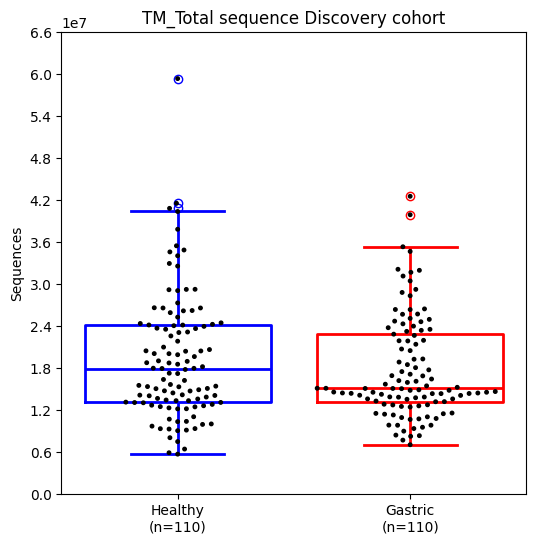

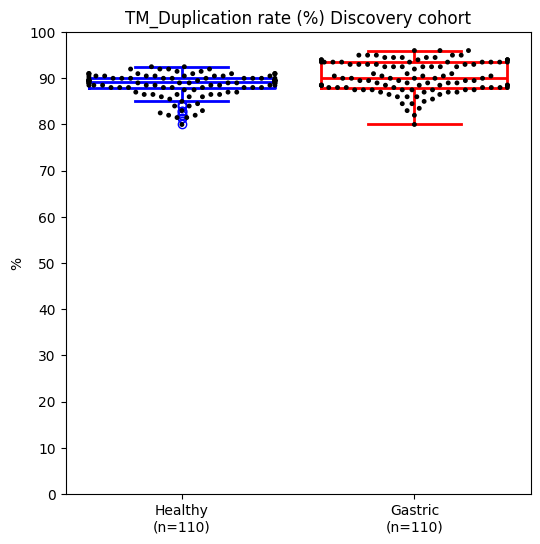

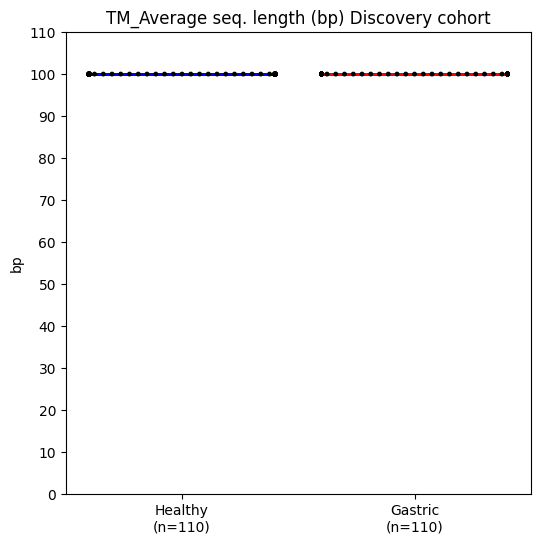

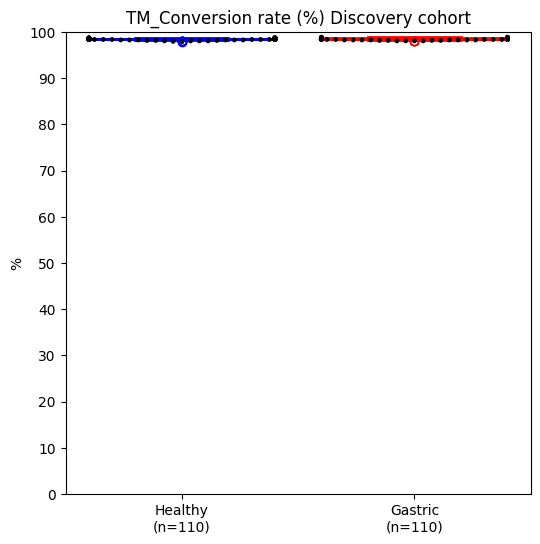

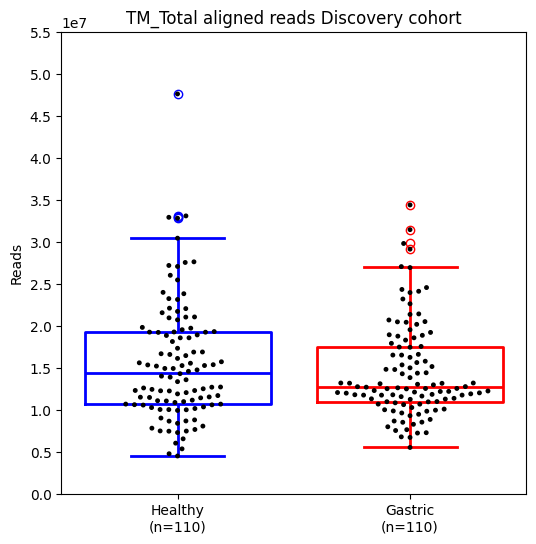

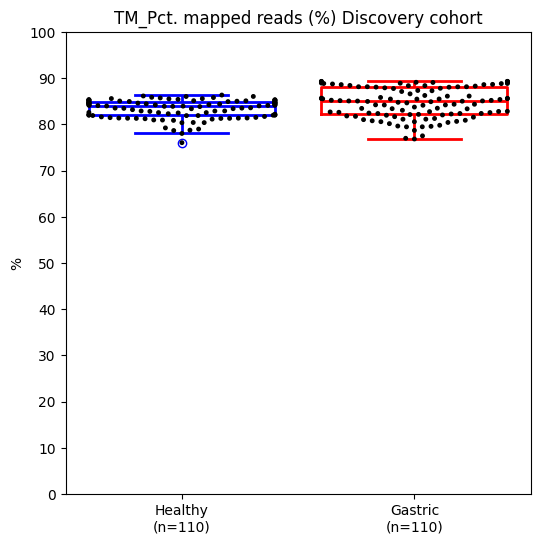

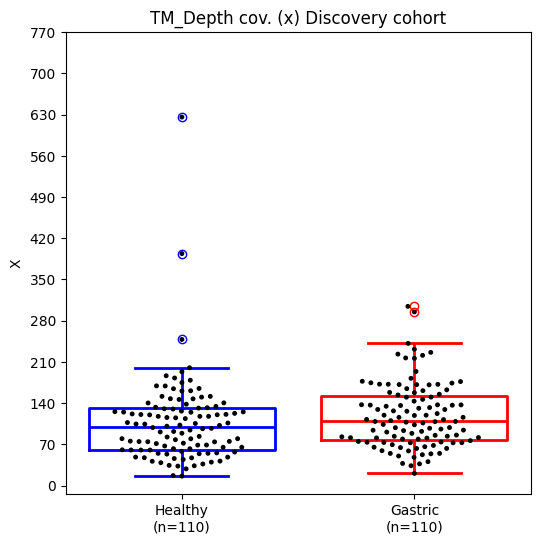

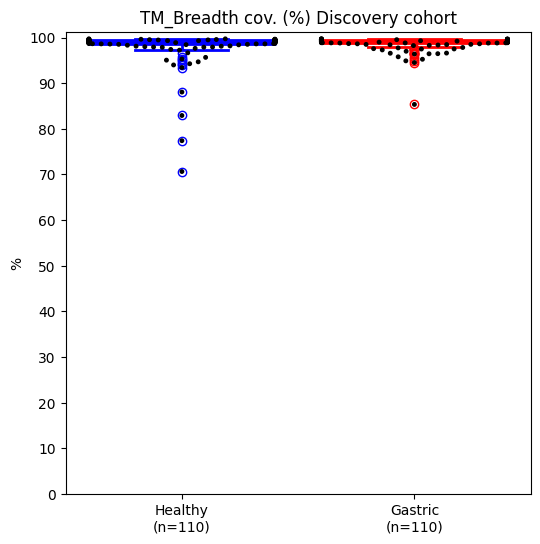

In [333]:
# Các thông số qc seq
# for y in co_horts:
y='Discovery'
df=data_qc[data_qc['Cohort']==y]
# col='Group'
for col in param_seq:
# col='GW_Total sequence'
    if (df[col].dtype!='object'): 
        if 'sequence' in col:
            ylabel='Sequences'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1
        elif 'rate' in col or 'Pct' in col or 'Breadth' in col:
            ylabel='%'
            stop=110
            step=10
        elif 'aligned' in col:
            ylabel='Reads'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1
        elif 'length' in col:
            ylabel='bp'
            stop=120
            step=10
        elif 'Depth' in col:
            ylabel='X'
            stop=introundup(max(df[col]))*1.1
            step=introundup(max(df[col]))*0.1
        # elif 'GW_Depth' in col:
        #     ylabel='X'
        #     stop=introundup(max(df[col]))*1.1
        #     step=introundup(max(df[col]))*0.1

        plt.figure(figsize=(6,6))
        ax=sb.swarmplot(data=df,x='Type',y=col,order=['Healthy','Gastric'],palette=['black'],marker='.',linewidth=1)
        ax=sb.boxplot(data=df,y=col,x='Type',palette=['b','r'],fill=False,linewidth=2,order=['Healthy','Gastric'])
        ax.set(xlabel=None)
        # sb.swarmplot(data=df,x='Class',y=col,palette=['b','g','orange','r'],marker='o',linewidth=1,order=[0,1,2,3])
        # sb.boxplot(data=df,y=col,x='Class',palette=['white'],order=[0,1,2,3])
        # plt.xlabel()
        plt.yticks(np.arange(0,stop,step))
        labels=[
            'Healthy\n(n='+str(len(data_qc_Discovery[data_qc_Discovery['Type']=='Healthy']))+')',
            'Gastric\n(n='+str(len(data_qc_Discovery[data_qc_Discovery['Type']=='Gastric']))+')',
        ]
        plt.xticks(ticks=[0,1],labels=labels,fontsize=10)
        plt.ylabel(ylabel)
    
        plt.title(col+' '+y+' cohort')

C:\Users\XN\AppData\Local\Temp\ipykernel_32152\2493892408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.swarmplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['black'],marker='.',linewidth=1,order=[0,1])
C:\Users\XN\AppData\Local\Temp\ipykernel_32152\2493892408.py:5: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sb.swarmplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['black'],marker='.',linewidth=1,order=[0,1])
C:\Users\XN\AppData\Local\Temp\ipykernel_32152\2493892408.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palet

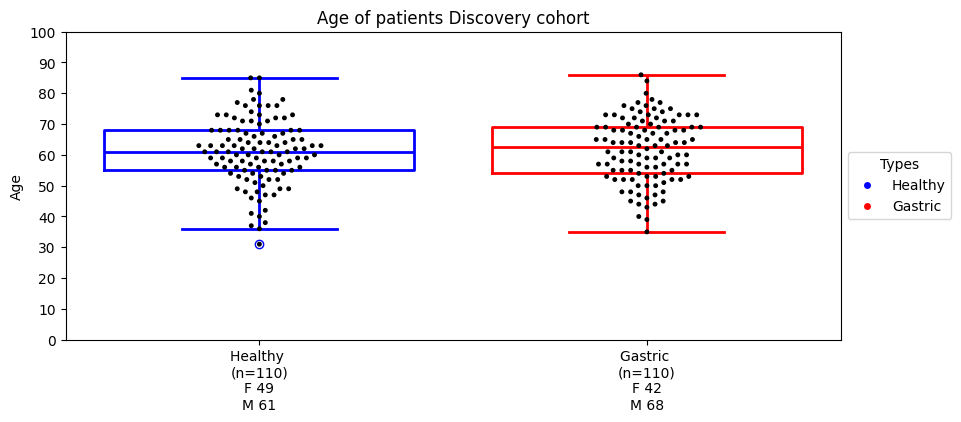

In [334]:
# Plot độ tuổi
for y in ['Discovery']:
# y='Discovery'
    plt.figure(figsize=(10,4))
    sb.swarmplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['black'],marker='.',linewidth=1,order=[0,1])
    sb.boxplot(data=data_qc[data_qc['Cohort']==y],y='Age',x='Label',palette=['b','r'],order=[0,1],fill=False,linewidth=2)
    plt.yticks(np.arange(0,110,10))
    labels_0='Healthy \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==0)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==0)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==0)&(data_qc['Gender']=='M')]))
    # labels_1='Gastritis \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='M')]))
    # labels_2='Pre_\ncancerous \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==2)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==2)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==2)&(data_qc['Gender']=='M')]))
    labels_3='Gastric \n(n='+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)]))+')\nF '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='F')]))+'\nM '+str(len(data_qc[(data_qc['Cohort']==y)&(data_qc['Label']==1)&(data_qc['Gender']=='M')]))
    plt.xticks(ticks=[0,1],labels=[labels_0,labels_3])
    custom_lines = [
                    Line2D([0], [0],marker='o',color='w', markerfacecolor='blue'),
                    # Line2D([0], [0],marker='o',color='w', markerfacecolor='g'),
                    # Line2D([0], [0],marker='o',color='w', markerfacecolor='orange'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r')
                    ]
    plt.legend(custom_lines,['Healthy','Gastric'],title='Types',loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('')
    plt.title('Age of patients '+y+' cohort')

## Load data_all

In [335]:
list_columns_vlookup=['Cohort','Class','Type','Age','Gender','Run TM',
                    #   'Run GW'
                      ]

In [336]:
col_start=len(list_columns_vlookup)+1
col_start

7

## DEFINE FEA AND PAIR

In [337]:
features=[
        'TMD',
          # 'GWMD','CNA','flen','MOTIF_END','GWFP_long','GWFP_short','GWFP_total','GWFP_ratio',
        #   'MOTIF21',
          'TMCNA','TMRATIOSL','TMRATIOST',
          'TMFLEN','TMEM'
        #   'ALL','ALL21',
        #   'ALL21TM',
        #   'CONCAT','CONCAT21',
        #   'CONCAT21TM'
          ]
features

['TMD', 'TMCNA', 'TMRATIOSL', 'TMRATIOST', 'TMFLEN', 'TMEM']

## Features path

In [338]:
path_f={
    'TMD':r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\TMD.csv",
    'TMCNA':r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\TMCNA.csv",
    'TMRATIOSL':r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\TMRATIOSL.csv",
    'TMRATIOST':r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\TMRATIOST.csv",
    'TMFLEN':r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\TMFLEN.csv",
    'TMEM':r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\TMEM.csv"
}

In [339]:
c=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\TMD_feature_name.csv")
c

,chrom,feature_name,CHR,start,end,gene,location,region code
0,chr1,TMD_1,1,1163599,1163832,C1orf159_TTLL10,1:1163599-1163832,1
1,chr1,TMD_2,1,2443865,2444245,PEX10_PLCH2,1:2443865-2444245,2
2,chr1,TMD_3,1,2789325,2789609,ACTRT2_MMEL1,1:2789325-2789609,3
3,chr1,TMD_4,1,2789723,2790126,ACTRT2_MMEL1,1:2789723-2790126,4
4,chr1,TMD_5,1,6064999,6065249,KCNAB2_CHD5,1:6064999-6065249,5
...,...,...,...,...,...,...,...,...
445,chr22,TMD_286,22,27799853,27800150,MN1,22:27799853-27800150,286
446,chr22,TMD_287,22,46007845,46008261,PPARA_WNT7B,22:46007845-46008261,287
447,chr22,TMD_288,22,46525740,46525932,CELSR1_TRMU,22:46525740-46525932,288
448,chr22,TMD_289,22,50548840,50549077,TYMP_SYCE3,22:50548840-50549077,289


In [340]:
ranges=[str(s)+'-'+str(e) for s, e in zip(list(c['start']),list(c['end']))]
feature_names=[n.split('_')[1] for n in list(c['feature_name'])]

## TMD

In [341]:
TMD=pd.read_csv(path_f['TMD'])
TMD.drop(['SampleID_Run_TM','Run_TM'],axis=1,inplace=True)
TMD
TMD

,SampleID,TMD_1,TMD_2,TMD_3,TMD_4,TMD_5,TMD_6,TMD_7,TMD_8,TMD_9,...,TMD_442,TMD_443,TMD_444,TMD_445,TMD_446,TMD_447,TMD_448,TMD_449,TMD_450,TMD_451
0,HNGK059,95.6522,5.97015,6.69856,3.50877,91.3580,94.8718,100.0000,30.4348,3.84615,...,3.007520,5.83942,1.44928,2.32558,4.28571,0.00000,92.5926,1.58730,38.8889,1.960780
1,HNGK061,95.8175,8.43373,7.88288,12.73410,92.9293,98.3607,92.8571,23.4043,13.72550,...,2.197800,1.66113,4.06091,20.77920,0.00000,0.00000,90.8571,4.95496,30.0000,1.481480
2,HNGK067,98.0583,5.44218,10.00000,7.02479,94.1558,90.0000,91.6667,10.9272,14.33450,...,3.026320,6.26667,6.59134,15.29410,8.13953,4.76190,92.3077,3.50877,39.8438,1.544400
3,HNGK068,95.4217,6.63265,4.93827,7.16912,90.8137,90.9524,95.6522,16.7808,10.10100,...,3.707870,4.91573,4.85762,11.57890,1.29450,0.00000,91.2214,5.31178,42.1875,0.715990
4,HNGK100,98.9474,3.27869,3.53261,4.42177,90.5405,93.7500,100.0000,13.6126,24.37500,...,2.158270,1.00251,8.69565,19.74250,0.00000,25.00000,95.7747,2.66667,41.7910,0.420168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,97.1429,9.09091,3.22581,7.35294,95.0000,91.2621,93.7500,16.6667,34.15840,...,3.469080,1.60481,6.29921,11.52740,14.52510,5.26316,90.4762,7.09677,43.8202,14.492800
275,HNGK200,96.0744,13.66910,4.92327,8.28685,95.0739,97.0370,96.9697,29.4559,20.10870,...,2.071250,7.39817,3.26945,10.48850,8.13953,4.54545,87.8882,1.11111,26.0563,1.408450
276,HNGK201,95.6873,6.68790,2.93848,7.64045,94.4954,88.5496,96.4912,16.3842,19.79170,...,0.594732,1.63934,3.86965,7.97963,7.26644,5.26316,90.2098,1.24688,36.0000,2.583030
277,HNGK202,96.1083,17.76320,15.83920,6.88817,94.1176,93.8650,93.1818,15.4887,26.78060,...,1.768610,2.46821,2.48027,12.62330,5.38244,0.00000,88.8350,3.13779,35.1852,2.173910


## TMCNA

In [342]:
# TMCNA=pd.read_csv('TM_CNA.csv')
TMCNA=pd.read_csv(path_f['TMCNA'])
TMCNA

,SampleID_Run_TM,SampleID,Run_TM,1:1163599-1163832,1:2443865-2444245,1:2789325-2789609,1:2789723-2790126,1:6064999-6065249,1:7668718-7668819,1:7668966-7668971,...,22:19767183-19767448,22:20280279-20280448,22:20438412-20438611,22:21652304-21652421,22:26050281-26050416,22:27799853-27800150,22:46007845-46008261,22:46525740-46525932,22:50548840-50549077,22:50577928-50578179
0,HNGK059_R9017,HNGK059,R9017,0.535088,0.236842,0.210526,1.368421,0.929825,0.201754,1.035088,...,0.421053,0.096491,0.359649,2.368421,0.964912,8.000000,0.543860,1.728070,0.192982,0.052632
1,HNGK061_R9017,HNGK061,R9017,0.739003,0.310850,0.334311,1.313783,1.079179,0.234604,1.008798,...,0.381232,0.146628,0.492669,2.480938,1.061584,7.818182,0.568915,1.788856,0.164223,0.076246
2,HNGK067_R9017,HNGK067,R9017,0.738532,0.321101,0.316514,1.068807,1.509174,0.412844,0.885321,...,0.522936,0.183486,0.628440,2.247706,1.192661,7.344037,0.802752,1.825688,0.252294,0.123853
3,HNGK068_R9017,HNGK068,R9017,0.769231,0.445759,0.493097,1.285996,1.159763,0.481262,0.990138,...,0.429980,0.276134,0.690335,1.936884,1.211045,7.096647,0.915187,1.633136,0.260355,0.169625
4,HNGK100_R9017,HNGK100,R9017,0.798507,0.328358,0.320896,1.701493,1.425373,0.276119,0.932836,...,0.574627,0.216418,0.447761,2.298507,1.395522,8.470149,0.686567,1.977612,0.149254,0.179104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199_R9077,HNGK199,R9077,0.888283,0.310627,0.441417,1.776567,1.237057,0.332425,0.735695,...,0.337875,0.179837,0.621253,1.841962,0.926431,6.991826,0.850136,1.743869,0.250681,0.114441
275,HNGK200_R9077,HNGK200,R9077,0.725564,0.567669,0.774436,1.522556,1.214286,0.274436,0.657895,...,0.421053,0.195489,0.601504,1.770677,0.909774,5.736842,0.917293,1.710526,0.379699,0.172932
276,HNGK201_R9077,HNGK201,R9077,0.845987,0.511931,0.650759,1.665944,1.032538,0.277657,0.659436,...,0.455531,0.112798,0.325380,1.696312,1.045553,6.459870,1.019523,1.722343,0.329718,0.134490
277,HNGK202_R9077,HNGK202,R9077,0.878676,0.496324,0.643382,1.625000,1.382353,0.378676,0.772059,...,0.382353,0.264706,0.595588,1.852941,1.058824,6.378676,1.088235,1.753676,0.393382,0.231618


In [343]:
col_names=['SampleID_Run_TM','SampleID','Run_TM']
for col in list(TMCNA.columns)[3:]:
    range1=col.split(':')[1]
    ind=ranges.index(range1)
    # col_names+=['TM_CNA_'+col.split(':')[0]+':'+feature_names[ind]]
    col_names+=['TMCNA_'+feature_names[ind]]
TMCNA.columns=col_names
TMCNA.drop(['SampleID_Run_TM','Run_TM'],axis=1,inplace=True)
TMCNA

,SampleID,TMCNA_1,TMCNA_2,TMCNA_3,TMCNA_4,TMCNA_5,TMCNA_6,TMCNA_7,TMCNA_8,TMCNA_9,...,TMCNA_281,TMCNA_282,TMCNA_283,TMCNA_284,TMCNA_285,TMCNA_286,TMCNA_287,TMCNA_288,TMCNA_289,TMCNA_290
0,HNGK059,0.535088,0.236842,0.210526,1.368421,0.929825,0.201754,1.035088,3.070175,6.350877,...,0.421053,0.096491,0.359649,2.368421,0.964912,8.000000,0.543860,1.728070,0.192982,0.052632
1,HNGK061,0.739003,0.310850,0.334311,1.313783,1.079179,0.234604,1.008798,3.102639,6.240469,...,0.381232,0.146628,0.492669,2.480938,1.061584,7.818182,0.568915,1.788856,0.164223,0.076246
2,HNGK067,0.738532,0.321101,0.316514,1.068807,1.509174,0.412844,0.885321,3.155963,5.903670,...,0.522936,0.183486,0.628440,2.247706,1.192661,7.344037,0.802752,1.825688,0.252294,0.123853
3,HNGK068,0.769231,0.445759,0.493097,1.285996,1.159763,0.481262,0.990138,2.666667,5.905325,...,0.429980,0.276134,0.690335,1.936884,1.211045,7.096647,0.915187,1.633136,0.260355,0.169625
4,HNGK100,0.798507,0.328358,0.320896,1.701493,1.425373,0.276119,0.932836,2.746269,6.828358,...,0.574627,0.216418,0.447761,2.298507,1.395522,8.470149,0.686567,1.977612,0.149254,0.179104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,0.888283,0.310627,0.441417,1.776567,1.237057,0.332425,0.735695,2.397820,4.762943,...,0.337875,0.179837,0.621253,1.841962,0.926431,6.991826,0.850136,1.743869,0.250681,0.114441
275,HNGK200,0.725564,0.567669,0.774436,1.522556,1.214286,0.274436,0.657895,2.379699,5.048872,...,0.421053,0.195489,0.601504,1.770677,0.909774,5.736842,0.917293,1.710526,0.379699,0.172932
276,HNGK201,0.845987,0.511931,0.650759,1.665944,1.032538,0.277657,0.659436,2.394794,4.728850,...,0.455531,0.112798,0.325380,1.696312,1.045553,6.459870,1.019523,1.722343,0.329718,0.134490
277,HNGK202,0.878676,0.496324,0.643382,1.625000,1.382353,0.378676,0.772059,2.533088,5.341912,...,0.382353,0.264706,0.595588,1.852941,1.058824,6.378676,1.088235,1.753676,0.393382,0.231618


## TMEM

In [344]:
TMEM=pd.read_csv(path_f['TMEM'])
TMEM

,SampleID_Run_TM,SampleID,Run_TM,TTTT_chr1:1163599-1163832,TTTT_chr1:2443865-2444245,TTTT_chr1:2789325-2789609,TTTT_chr1:2789723-2790126,TTTT_chr1:6064999-6065249,TTTT_chr1:7668718-7668819,TTTT_chr1:7668966-7668971,...,AAAA_chr9:97853977-97854388,AAAA_chr9:117744892-117745189,AAAA_chr9:124016065-124016323,AAAA_chr9:124503413-124503621,AAAA_chr9:129888368-129888598,AAAA_chr9:129888745-129888845,AAAA_chr9:130896111-130896371,AAAA_chr9:132587027-132587206,AAAA_chr9:136534110-136534227,AAAA_chr9:21974678-21974780
0,HNGK059_R9017,HNGK059,R9017,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,HNGK061_R9017,HNGK061,R9017,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.058824,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,HNGK067_R9017,HNGK067,R9017,0.0,0.0,0.000000,0.0,0.028571,0.0,0.0,...,0.032258,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,HNGK068_R9017,HNGK068,R9017,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.019231,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.029412,0.0
4,HNGK100_R9017,HNGK100,R9017,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199_R9077,HNGK199,R9077,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.015385,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
275,HNGK200_R9077,HNGK200,R9077,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
276,HNGK201_R9077,HNGK201,R9077,0.0,0.0,0.012821,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
277,HNGK202_R9077,HNGK202,R9077,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.033898,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [345]:
col_names=['SampleID_Run_TM','SampleID','Run_TM']
for col in list(TMEM.columns)[3:]:
    range1=col.split(':')[1]
    ind=ranges.index(range1)
    col_names+=['TMEM_'+feature_names[ind]+'_'+col.split('_')[0]]
TMEM.columns=col_names
TMEM.drop(['SampleID_Run_TM','Run_TM'],axis=1,inplace=True)
TMEM

,SampleID,TMEM_1_TTTT,TMEM_2_TTTT,TMEM_3_TTTT,TMEM_4_TTTT,TMEM_5_TTTT,TMEM_6_TTTT,TMEM_7_TTTT,TMEM_8_TTTT,TMEM_9_TTTT,...,TMEM_442_AAAA,TMEM_443_AAAA,TMEM_444_AAAA,TMEM_445_AAAA,TMEM_446_AAAA,TMEM_447_AAAA,TMEM_448_AAAA,TMEM_449_AAAA,TMEM_450_AAAA,TMEM_451_AAAA
0,HNGK059,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.055556,...,0.000000,0.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,HNGK061,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.058824,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,HNGK067,0.0,0.0,0.000000,0.0,0.028571,0.0,0.0,0.000000,0.000000,...,0.032258,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,HNGK068,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.050000,0.000000,...,0.019231,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.029412,0.0
4,HNGK100,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.040000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.212121,0.000000,...,0.000000,0.015385,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
275,HNGK200,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
276,HNGK201,0.0,0.0,0.012821,0.0,0.000000,0.0,0.0,0.050000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
277,HNGK202,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.033898,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


## TMFLEN

In [346]:
TMFLEN=pd.read_csv(path_f['TMFLEN'])
TMFLEN

,SampleID_Run_TM,SampleID,Run_TM,250_chr1:1163599-1163832,250_chr1:2443865-2444245,250_chr1:2789325-2789609,250_chr1:2789723-2790126,250_chr1:6064999-6065249,250_chr1:7668718-7668819,250_chr1:7668966-7668971,...,100_chr9:97853977-97854388,100_chr9:117744892-117745189,100_chr9:124016065-124016323,100_chr9:124503413-124503621,100_chr9:129888368-129888598,100_chr9:129888745-129888845,100_chr9:130896111-130896371,100_chr9:132587027-132587206,100_chr9:136534110-136534227,100_chr9:21974678-21974780
0,HNGK059_R9017,HNGK059,R9017,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,HNGK061_R9017,HNGK061,R9017,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2,HNGK067_R9017,HNGK067,R9017,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000,0.000000,0.031746,0.000000,0.026316,0.000000,0.000000,0.000000,0.0,0.0
3,HNGK068_R9017,HNGK068,R9017,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,HNGK100_R9017,HNGK100,R9017,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199_R9077,HNGK199,R9077,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000,0.013986,0.000000,0.000000,0.031746,0.066667,0.000000,0.000000,0.0,0.0
275,HNGK200_R9077,HNGK200,R9077,0.0,0.000000,0.007752,0.0,0.0,0.0,0.0,...,0.000,0.000000,0.000000,0.022989,0.020202,0.000000,0.013423,0.027397,0.0,0.0
276,HNGK201_R9077,HNGK201,R9077,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000,0.000000,0.000000,0.000000,0.023256,0.000000,0.000000,0.000000,0.0,0.0
277,HNGK202_R9077,HNGK202,R9077,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000,0.000000,0.000000,0.000000,0.000000,0.036364,0.000000,0.000000,0.0,0.0


In [347]:
col_names=['SampleID_Run_TM','SampleID','Run_TM']
for col in list(TMFLEN.columns)[3:]:
    range1=col.split(':')[1]
    ind=ranges.index(range1)
    col_names+=['TMFLEN_'+feature_names[ind]+'_'+col.split('_')[0]]
TMFLEN.columns=col_names
TMFLEN.drop(['SampleID_Run_TM','Run_TM'],axis=1,inplace=True)
TMFLEN

,SampleID,TMFLEN_1_250,TMFLEN_2_250,TMFLEN_3_250,TMFLEN_4_250,TMFLEN_5_250,TMFLEN_6_250,TMFLEN_7_250,TMFLEN_8_250,TMFLEN_9_250,...,TMFLEN_442_100,TMFLEN_443_100,TMFLEN_444_100,TMFLEN_445_100,TMFLEN_446_100,TMFLEN_447_100,TMFLEN_448_100,TMFLEN_449_100,TMFLEN_450_100,TMFLEN_451_100
0,HNGK059,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,HNGK061,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.030303,0.0,...,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2,HNGK067,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000,0.000000,0.031746,0.000000,0.026316,0.000000,0.000000,0.000000,0.0,0.0
3,HNGK068,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,HNGK100,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000,0.013986,0.000000,0.000000,0.031746,0.066667,0.000000,0.000000,0.0,0.0
275,HNGK200,0.0,0.000000,0.007752,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000,0.000000,0.000000,0.022989,0.020202,0.000000,0.013423,0.027397,0.0,0.0
276,HNGK201,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000,0.000000,0.000000,0.000000,0.023256,0.000000,0.000000,0.000000,0.0,0.0
277,HNGK202,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000,0.000000,0.000000,0.000000,0.000000,0.036364,0.000000,0.000000,0.0,0.0


## TMRATIOSL

In [348]:
TMRATIOSL=pd.read_csv(path_f['TMRATIOSL'])
TMRATIOSL

,SampleID_Run_TM,SampleID,Run_TM,1:109792189-109792254,1:109792367-109792397,1:110069838-110070192,1:110083552-110083775,1:111270865-111271077,1:111271216-111271381,1:1163599-1163832,...,9:13323139-13323351,9:136534110-136534227,9:14346834-14347128,9:19788616-19788772,9:19789007-19789198,9:21974678-21974780,9:27690518-27690700,9:36986086-36986754,9:36986901-36987144,9:97853977-97854388
0,HNGK059_R9017,HNGK059,R9017,0.000000,0.461538,1.666667,0.425926,0.500000,0.747368,0.685714,...,0.676471,0.000000,0.547059,0.000000,0.750000,0.544776,0.619718,0.461538,0.516736,0.507491
1,HNGK061_R9017,HNGK061,R9017,0.263158,0.500000,0.612903,0.951220,0.444444,0.525292,0.303371,...,0.380952,1.142857,0.587786,0.222222,0.580952,0.773050,0.557047,0.387755,0.510590,0.535813
2,HNGK067_R9017,HNGK067,R9017,0.800000,0.800000,0.725000,1.025641,1.153846,1.166038,1.121622,...,0.803279,1.153846,0.751534,0.714286,1.050633,1.190476,1.009494,0.846939,1.026037,1.011173
3,HNGK068_R9017,HNGK068,R9017,1.160000,0.837838,0.651163,0.989899,0.615385,0.953020,0.916667,...,0.703704,0.380952,0.753927,0.411765,0.750000,1.095890,0.860465,1.126866,0.759322,0.901449
4,HNGK100_R9017,HNGK100,R9017,0.857143,0.400000,0.370370,0.974359,0.500000,0.806818,0.741379,...,0.357143,1.250000,0.563877,2.285714,0.602564,0.776786,0.813008,0.437500,0.686441,0.744318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199_R9077,HNGK199,R9077,0.562500,0.419355,0.731707,1.079365,1.187500,0.758364,1.039474,...,0.746479,0.090909,0.537102,1.375000,0.857143,0.901408,0.678233,0.586207,0.692586,0.819728
275,HNGK200_R9077,HNGK200,R9077,1.433333,0.714286,1.234043,1.485714,1.550000,0.848101,1.102273,...,1.194444,0.375000,0.835294,0.914286,1.345679,1.037500,0.762274,1.359649,1.033844,1.172911
276,HNGK201_R9077,HNGK201,R9077,1.250000,0.382979,0.692308,0.921053,0.740741,0.628125,0.909091,...,1.014925,1.166667,0.599407,0.620690,0.697917,0.787879,0.640483,0.831858,0.609407,0.644208
277,HNGK202_R9077,HNGK202,R9077,1.352941,0.612245,0.678161,0.685185,1.155172,0.826531,0.895161,...,1.187500,1.916667,0.989899,1.107143,0.772277,0.843373,1.152824,1.250000,0.982523,1.165205


In [349]:
col_names=['SampleID_Run_TM','SampleID','Run_TM']
for col in list(TMRATIOSL.columns)[3:]:
    range1=col.split(':')[1]
    ind=ranges.index(range1)
    # col_names+=['TM_CNA_'+col.split(':')[0]+':'+feature_names[ind]]
    col_names+=['TMRATIOSL_'+feature_names[ind]]
TMRATIOSL.columns=col_names
TMRATIOSL.drop(['SampleID_Run_TM','Run_TM'],axis=1,inplace=True)
TMRATIOSL

,SampleID,TMRATIOSL_20,TMRATIOSL_21,TMRATIOSL_22,TMRATIOSL_23,TMRATIOSL_24,TMRATIOSL_25,TMRATIOSL_1,TMRATIOSL_26,TMRATIOSL_27,...,TMRATIOSL_435,TMRATIOSL_450,TMRATIOSL_436,TMRATIOSL_437,TMRATIOSL_438,TMRATIOSL_451,TMRATIOSL_439,TMRATIOSL_440,TMRATIOSL_441,TMRATIOSL_442
0,HNGK059,0.000000,0.461538,1.666667,0.425926,0.500000,0.747368,0.685714,0.857143,0.235294,...,0.676471,0.000000,0.547059,0.000000,0.750000,0.544776,0.619718,0.461538,0.516736,0.507491
1,HNGK061,0.263158,0.500000,0.612903,0.951220,0.444444,0.525292,0.303371,0.222222,0.238095,...,0.380952,1.142857,0.587786,0.222222,0.580952,0.773050,0.557047,0.387755,0.510590,0.535813
2,HNGK067,0.800000,0.800000,0.725000,1.025641,1.153846,1.166038,1.121622,0.666667,1.014925,...,0.803279,1.153846,0.751534,0.714286,1.050633,1.190476,1.009494,0.846939,1.026037,1.011173
3,HNGK068,1.160000,0.837838,0.651163,0.989899,0.615385,0.953020,0.916667,0.382353,0.421875,...,0.703704,0.380952,0.753927,0.411765,0.750000,1.095890,0.860465,1.126866,0.759322,0.901449
4,HNGK100,0.857143,0.400000,0.370370,0.974359,0.500000,0.806818,0.741379,0.615385,1.357143,...,0.357143,1.250000,0.563877,2.285714,0.602564,0.776786,0.813008,0.437500,0.686441,0.744318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,0.562500,0.419355,0.731707,1.079365,1.187500,0.758364,1.039474,1.277778,0.766667,...,0.746479,0.090909,0.537102,1.375000,0.857143,0.901408,0.678233,0.586207,0.692586,0.819728
275,HNGK200,1.433333,0.714286,1.234043,1.485714,1.550000,0.848101,1.102273,1.147059,1.464286,...,1.194444,0.375000,0.835294,0.914286,1.345679,1.037500,0.762274,1.359649,1.033844,1.172911
276,HNGK201,1.250000,0.382979,0.692308,0.921053,0.740741,0.628125,0.909091,0.903226,1.620690,...,1.014925,1.166667,0.599407,0.620690,0.697917,0.787879,0.640483,0.831858,0.609407,0.644208
277,HNGK202,1.352941,0.612245,0.678161,0.685185,1.155172,0.826531,0.895161,0.897436,0.770270,...,1.187500,1.916667,0.989899,1.107143,0.772277,0.843373,1.152824,1.250000,0.982523,1.165205


## TMRATIOST

In [350]:
TMRATIOST=pd.read_csv(path_f['TMRATIOST'])
TMRATIOST

,SampleID_Run_TM,SampleID,Run_TM,1:109792189-109792254,1:109792367-109792397,1:110069838-110070192,1:110083552-110083775,1:111270865-111271077,1:111271216-111271381,1:1163599-1163832,...,9:13323139-13323351,9:136534110-136534227,9:14346834-14347128,9:19788616-19788772,9:19789007-19789198,9:21974678-21974780,9:27690518-27690700,9:36986086-36986754,9:36986901-36987144,9:97853977-97854388
0,HNGK059_R9017,HNGK059,R9017,0.000000,0.315789,0.625000,0.298701,0.333333,0.427711,0.406780,...,0.403509,0.000000,0.353612,0.000000,0.428571,0.352657,0.382609,0.315789,0.340690,0.336646
1,HNGK061_R9017,HNGK061,R9017,0.208333,0.333333,0.380000,0.487500,0.307692,0.344388,0.232759,...,0.275862,0.533333,0.370192,0.181818,0.367470,0.436000,0.357759,0.279412,0.338007,0.348879
2,HNGK067_R9017,HNGK067,R9017,0.444444,0.444444,0.420290,0.506329,0.535714,0.538328,0.528662,...,0.445455,0.535714,0.429072,0.416667,0.512346,0.543478,0.502362,0.458564,0.506426,0.502778
3,HNGK068_R9017,HNGK068,R9017,0.537037,0.455882,0.394366,0.497462,0.380952,0.487973,0.478261,...,0.413043,0.275862,0.429851,0.291667,0.428571,0.522876,0.462500,0.529825,0.431599,0.474085
4,HNGK100_R9017,HNGK100,R9017,0.461538,0.285714,0.270270,0.493506,0.333333,0.446541,0.425743,...,0.263158,0.555556,0.360563,0.695652,0.376000,0.437186,0.448430,0.304348,0.407035,0.426710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199_R9077,HNGK199,R9077,0.360000,0.295455,0.422535,0.519084,0.542857,0.431290,0.509677,...,0.427419,0.083333,0.349425,0.578947,0.461538,0.474074,0.404135,0.369565,0.409188,0.450467
275,HNGK200_R9077,HNGK200,R9077,0.589041,0.416667,0.552381,0.597701,0.607843,0.458904,0.524324,...,0.544304,0.272727,0.455128,0.477612,0.573684,0.509202,0.432551,0.576208,0.508320,0.539788
276,HNGK201_R9077,HNGK201,R9077,0.555556,0.276923,0.409091,0.479452,0.425532,0.385797,0.476190,...,0.503704,0.538462,0.374768,0.382979,0.411043,0.440678,0.390424,0.454106,0.378653,0.391804
277,HNGK202_R9077,HNGK202,R9077,0.575000,0.379747,0.404110,0.406593,0.536000,0.452514,0.472340,...,0.542857,0.657143,0.497462,0.525424,0.435754,0.457516,0.535494,0.555556,0.495592,0.538150


In [351]:
col_names=['SampleID_Run_TM','SampleID','Run_TM']
for col in list(TMRATIOST.columns)[3:]:
    range1=col.split(':')[1]
    ind=ranges.index(range1)
    # col_names+=['TM_CNA_'+col.split(':')[0]+':'+feature_names[ind]]
    col_names+=['TMRATIOST_'+feature_names[ind]]
TMRATIOST.columns=col_names
TMRATIOST.drop(['SampleID_Run_TM','Run_TM'],axis=1,inplace=True)
TMRATIOST

,SampleID,TMRATIOST_20,TMRATIOST_21,TMRATIOST_22,TMRATIOST_23,TMRATIOST_24,TMRATIOST_25,TMRATIOST_1,TMRATIOST_26,TMRATIOST_27,...,TMRATIOST_435,TMRATIOST_450,TMRATIOST_436,TMRATIOST_437,TMRATIOST_438,TMRATIOST_451,TMRATIOST_439,TMRATIOST_440,TMRATIOST_441,TMRATIOST_442
0,HNGK059,0.000000,0.315789,0.625000,0.298701,0.333333,0.427711,0.406780,0.461538,0.190476,...,0.403509,0.000000,0.353612,0.000000,0.428571,0.352657,0.382609,0.315789,0.340690,0.336646
1,HNGK061,0.208333,0.333333,0.380000,0.487500,0.307692,0.344388,0.232759,0.181818,0.192308,...,0.275862,0.533333,0.370192,0.181818,0.367470,0.436000,0.357759,0.279412,0.338007,0.348879
2,HNGK067,0.444444,0.444444,0.420290,0.506329,0.535714,0.538328,0.528662,0.400000,0.503704,...,0.445455,0.535714,0.429072,0.416667,0.512346,0.543478,0.502362,0.458564,0.506426,0.502778
3,HNGK068,0.537037,0.455882,0.394366,0.497462,0.380952,0.487973,0.478261,0.276596,0.296703,...,0.413043,0.275862,0.429851,0.291667,0.428571,0.522876,0.462500,0.529825,0.431599,0.474085
4,HNGK100,0.461538,0.285714,0.270270,0.493506,0.333333,0.446541,0.425743,0.380952,0.575758,...,0.263158,0.555556,0.360563,0.695652,0.376000,0.437186,0.448430,0.304348,0.407035,0.426710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,HNGK199,0.360000,0.295455,0.422535,0.519084,0.542857,0.431290,0.509677,0.560976,0.433962,...,0.427419,0.083333,0.349425,0.578947,0.461538,0.474074,0.404135,0.369565,0.409188,0.450467
275,HNGK200,0.589041,0.416667,0.552381,0.597701,0.607843,0.458904,0.524324,0.534247,0.594203,...,0.544304,0.272727,0.455128,0.477612,0.573684,0.509202,0.432551,0.576208,0.508320,0.539788
276,HNGK201,0.555556,0.276923,0.409091,0.479452,0.425532,0.385797,0.476190,0.474576,0.618421,...,0.503704,0.538462,0.374768,0.382979,0.411043,0.440678,0.390424,0.454106,0.378653,0.391804
277,HNGK202,0.575000,0.379747,0.404110,0.406593,0.536000,0.452514,0.472340,0.472973,0.435115,...,0.542857,0.657143,0.497462,0.525424,0.435754,0.457516,0.535494,0.555556,0.495592,0.538150


## PAIR

In [352]:
PAIR=[
    'Healthy vs Gastric',
      ]

## Fea

In [353]:
fea={
    'TMD':TMD,
    'TMCNA':TMCNA,
    'TMRATIOSL':TMRATIOSL,
    'TMRATIOST':TMRATIOST,
    'TMFLEN':TMFLEN,
    'TMEM':TMEM
    }

In [354]:
for f in features:
    fea[f]=fea[f][fea[f]['SampleID'].isin(list(data_qc_Discovery['SampleID']))]
    for col in list_columns_vlookup:
        lst=[]
        for s in list(fea[f]['SampleID']):
            lst+=[data_qc_Discovery[data_qc_Discovery['SampleID']==s][col].reset_index(drop=True)[0]]
        fea[f].insert(loc=1,column=col,value=lst)
    fea[f].index=list(fea[f]['SampleID'])
    fea[f] = fea[f].replace([np.inf, -np.inf], 0).fillna(0)
    fea[f].sort_index()

In [355]:
for f in features:
    print(f,fea[f].shape)

TMD (220, 453)
TMCNA (220, 457)
TMRATIOSL (220, 457)
TMRATIOST (220, 457)
TMFLEN (220, 67957)
TMEM (220, 115207)


In [356]:
fea[f]

,SampleID,Run TM,Gender,Age,Type,Class,Cohort,TMEM_1_TTTT,TMEM_2_TTTT,TMEM_3_TTTT,...,TMEM_442_AAAA,TMEM_443_AAAA,TMEM_444_AAAA,TMEM_445_AAAA,TMEM_446_AAAA,TMEM_447_AAAA,TMEM_448_AAAA,TMEM_449_AAAA,TMEM_450_AAAA,TMEM_451_AAAA
HNGK059,HNGK059,R9017,M,48,Gastric,4.0,Discovery,0.0,0.0,0.000000,...,0.000000,0.200000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
HNGK100,HNGK100,R9017,M,63,Gastric,4.0,Discovery,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
HNGK113,HNGK113,R9017,M,68,Gastric,4.0,Discovery,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
HNGK114,HNGK114,R9017,F,65,Gastric,4.0,Discovery,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
HNGK115,HNGK115,R9017,M,55,Gastric,4.0,Discovery,0.0,0.0,0.000000,...,0.022222,0.017544,0.0,0.0,0.0,0.0,0.0,0.0,0.043478,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNGK198,HNGK198,R9077,M,61,Gastric,4.0,Discovery,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
HNGK200,HNGK200,R9077,F,64,Gastric,4.0,Discovery,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
HNGK201,HNGK201,R9077,M,50,Gastric,4.0,Discovery,0.0,0.0,0.012821,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
HNGK202,HNGK202,R9077,M,64,Gastric,4.0,Discovery,0.0,0.0,0.000000,...,0.000000,0.033898,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


# Entropy

In [357]:
lst_region={}

In [358]:
for f in ['TMFLEN','TMEM']:
    df=pd.DataFrame(fea[f].columns[col_start:])
    df['Region']=df[0].str.split('_').str[0] + '_' + df[0].str.split('_').str[1] #+ '_' + df[0].str.split('_').str[2]
    lst=list(df['Region'].drop_duplicates(keep='first'))
    lst_region[f]=lst

In [359]:
lst_region['TMFLEN']

['TMFLEN_1',
 'TMFLEN_2',
 'TMFLEN_3',
 'TMFLEN_4',
 'TMFLEN_5',
 'TMFLEN_6',
 'TMFLEN_7',
 'TMFLEN_8',
 'TMFLEN_9',
 'TMFLEN_10',
 'TMFLEN_11',
 'TMFLEN_12',
 'TMFLEN_13',
 'TMFLEN_14',
 'TMFLEN_15',
 'TMFLEN_16',
 'TMFLEN_17',
 'TMFLEN_18',
 'TMFLEN_19',
 'TMFLEN_20',
 'TMFLEN_21',
 'TMFLEN_22',
 'TMFLEN_23',
 'TMFLEN_24',
 'TMFLEN_25',
 'TMFLEN_26',
 'TMFLEN_27',
 'TMFLEN_28',
 'TMFLEN_29',
 'TMFLEN_30',
 'TMFLEN_31',
 'TMFLEN_32',
 'TMFLEN_33',
 'TMFLEN_34',
 'TMFLEN_35',
 'TMFLEN_36',
 'TMFLEN_37',
 'TMFLEN_38',
 'TMFLEN_39',
 'TMFLEN_40',
 'TMFLEN_41',
 'TMFLEN_42',
 'TMFLEN_43',
 'TMFLEN_44',
 'TMFLEN_45',
 'TMFLEN_46',
 'TMFLEN_47',
 'TMFLEN_48',
 'TMFLEN_49',
 'TMFLEN_50',
 'TMFLEN_51',
 'TMFLEN_52',
 'TMFLEN_53',
 'TMFLEN_54',
 'TMFLEN_55',
 'TMFLEN_56',
 'TMFLEN_57',
 'TMFLEN_58',
 'TMFLEN_59',
 'TMFLEN_60',
 'TMFLEN_61',
 'TMFLEN_62',
 'TMFLEN_63',
 'TMFLEN_64',
 'TMFLEN_65',
 'TMFLEN_66',
 'TMFLEN_67',
 'TMFLEN_68',
 'TMFLEN_69',
 'TMFLEN_70',
 'TMFLEN_71',
 'TMFLEN_72',
 

In [360]:
lst_region['TMEM']

['TMEM_1',
 'TMEM_2',
 'TMEM_3',
 'TMEM_4',
 'TMEM_5',
 'TMEM_6',
 'TMEM_7',
 'TMEM_8',
 'TMEM_9',
 'TMEM_10',
 'TMEM_11',
 'TMEM_12',
 'TMEM_13',
 'TMEM_14',
 'TMEM_15',
 'TMEM_16',
 'TMEM_17',
 'TMEM_18',
 'TMEM_19',
 'TMEM_20',
 'TMEM_21',
 'TMEM_22',
 'TMEM_23',
 'TMEM_24',
 'TMEM_25',
 'TMEM_26',
 'TMEM_27',
 'TMEM_28',
 'TMEM_29',
 'TMEM_30',
 'TMEM_31',
 'TMEM_32',
 'TMEM_33',
 'TMEM_34',
 'TMEM_35',
 'TMEM_36',
 'TMEM_37',
 'TMEM_38',
 'TMEM_39',
 'TMEM_40',
 'TMEM_41',
 'TMEM_42',
 'TMEM_43',
 'TMEM_44',
 'TMEM_45',
 'TMEM_46',
 'TMEM_47',
 'TMEM_48',
 'TMEM_49',
 'TMEM_50',
 'TMEM_51',
 'TMEM_52',
 'TMEM_53',
 'TMEM_54',
 'TMEM_55',
 'TMEM_56',
 'TMEM_57',
 'TMEM_58',
 'TMEM_59',
 'TMEM_60',
 'TMEM_61',
 'TMEM_62',
 'TMEM_63',
 'TMEM_64',
 'TMEM_65',
 'TMEM_66',
 'TMEM_67',
 'TMEM_68',
 'TMEM_69',
 'TMEM_70',
 'TMEM_71',
 'TMEM_72',
 'TMEM_73',
 'TMEM_74',
 'TMEM_75',
 'TMEM_76',
 'TMEM_77',
 'TMEM_78',
 'TMEM_79',
 'TMEM_80',
 'TMEM_81',
 'TMEM_82',
 'TMEM_83',
 'TMEM_84',
 

In [361]:
f='TMEM'

In [362]:
result=pd.DataFrame()
for region in lst_region[f]:
    df = fea[f].filter(regex=r'^('+region+')')
    value=[entropy(df.loc[s,:]) for s in list(df.index)]
    df.insert(loc=0, column=region, value=value)
    result=pd.concat([result,df[[region]]],axis=1)
    result = result.replace([np.inf, -np.inf], 0).fillna(0)
result.insert(loc=0,column='SampleID',value=list(result.index))

In [363]:
result

,SampleID,TMEM_1,TMEM_2,TMEM_3,TMEM_4,TMEM_5,TMEM_6,TMEM_7,TMEM_8,TMEM_9,...,TMEM_442,TMEM_443,TMEM_444,TMEM_445,TMEM_446,TMEM_447,TMEM_448,TMEM_449,TMEM_450,TMEM_451
HNGK059,HNGK059,6.224939,6.177083,6.204443,5.420227,3.984995,4.060399,3.804348,3.834622,3.981118,...,1.332179,1.834372,1.698783,0.693147,1.549826,1.386294,1.386294,0.693147,1.098612,1.386294
HNGK100,HNGK100,6.829136,6.820385,6.850152,6.082221,4.676937,4.833845,4.011596,4.786636,4.451238,...,2.631338,2.623522,2.690829,1.906155,2.552085,1.609438,2.138333,1.945910,1.906155,2.138397
HNGK113,HNGK113,7.335732,7.300674,7.348013,6.646003,5.085488,4.853731,4.676783,5.169422,4.762613,...,3.024696,2.698011,3.335077,1.945910,2.787331,2.853177,3.450286,2.540036,3.014947,2.341994
HNGK114,HNGK114,7.127444,7.140827,7.106183,6.421255,4.801995,4.921891,4.399839,4.967260,4.358805,...,2.824366,2.902002,3.416182,2.033662,2.938859,2.245035,2.867440,2.163956,1.889159,2.441015
HNGK115,HNGK115,7.766902,7.791217,7.822787,7.075643,5.507606,5.413810,5.220870,5.678842,5.124905,...,3.402101,3.669057,3.665101,2.564949,3.180867,2.604795,3.670349,3.183673,2.954673,2.712962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNGK198,HNGK198,7.537343,7.581648,7.661799,6.912330,5.447815,5.402434,4.919011,5.454212,5.016973,...,3.343371,3.259569,3.244407,2.751667,3.193512,2.894400,3.242889,2.630253,2.968392,2.351673
HNGK200,HNGK200,7.859934,7.931164,8.011525,7.226983,5.715533,5.725952,5.105995,5.747545,5.494694,...,3.544123,3.612327,3.910251,2.775614,3.114414,2.425480,3.701246,3.031515,2.690829,2.772589
HNGK201,HNGK201,7.731877,7.768234,7.826735,7.122123,5.597329,5.637594,5.185067,5.666883,5.242555,...,3.533038,3.416554,3.362711,2.684657,2.999816,2.532591,3.494162,3.047277,2.968392,2.338372
HNGK202,HNGK202,7.894316,7.947726,8.025283,7.261947,5.740763,5.814141,5.477447,5.792460,5.559503,...,3.462957,3.572133,3.668105,2.761626,3.336575,3.059489,3.641449,3.186589,3.113231,2.898594


In [364]:
f

'TMEM'

In [365]:
result.to_csv('ENT'+f+'.csv',index=False)

In [366]:
f='TMFLEN'

In [367]:
result=pd.DataFrame()
for region in lst_region[f]:
    df = fea[f].filter(regex=r'^('+region+')')
    value=[entropy(df.loc[s,:]) for s in list(df.index)]
    df.insert(loc=0, column=region, value=value)
    result=pd.concat([result,df[[region]]],axis=1)
    result = result.replace([np.inf, -np.inf], 0).fillna(0)
result.insert(loc=0,column='SampleID',value=list(result.index))

In [368]:
result

,SampleID,TMFLEN_1,TMFLEN_2,TMFLEN_3,TMFLEN_4,TMFLEN_5,TMFLEN_6,TMFLEN_7,TMFLEN_8,TMFLEN_9,...,TMFLEN_442,TMFLEN_443,TMFLEN_444,TMFLEN_445,TMFLEN_446,TMFLEN_447,TMFLEN_448,TMFLEN_449,TMFLEN_450,TMFLEN_451
HNGK059,HNGK059,6.698070,6.525344,6.650387,5.918323,4.367941,4.573368,4.076402,4.274772,4.376276,...,2.079442,2.007556,2.600431,1.329661,2.068885,1.332179,2.022809,1.054920,1.098612,1.386294
HNGK100,HNGK100,7.167316,7.239484,7.175142,6.465347,4.978892,5.043508,4.436762,5.026452,4.743412,...,3.170148,3.252050,3.178054,2.738078,2.833213,2.205598,2.313502,2.197225,2.775614,2.566752
HNGK113,HNGK113,7.660032,7.674602,7.714249,6.953744,5.520113,5.377828,4.960176,5.566365,5.019760,...,3.106099,3.197905,3.425295,2.166085,3.222632,3.489602,3.637620,2.629347,3.030206,3.099704
HNGK114,HNGK114,7.563332,7.521256,7.458907,6.834299,5.287472,5.355298,4.772151,5.360536,4.872148,...,3.245427,3.254569,3.390644,2.690829,3.187788,2.830713,3.319314,2.587976,2.466577,2.802434
HNGK115,HNGK115,8.087289,8.099427,8.039521,7.289307,5.774810,5.674921,5.457825,6.016035,5.559796,...,3.591700,3.927669,3.846771,2.763200,3.285993,2.992197,3.809778,3.089484,3.174590,3.080913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNGK198,HNGK198,7.950452,8.060242,8.014092,7.333830,5.805027,5.789993,5.277396,5.926791,5.565334,...,3.680925,3.573766,3.921766,2.815548,3.232638,2.708621,3.602782,3.035718,3.037182,2.772589
HNGK200,HNGK200,8.200602,8.279240,8.255696,7.590586,6.036697,5.906520,5.611593,6.076269,5.824272,...,3.758258,3.820652,3.907637,3.635416,3.665638,2.945876,3.892344,3.264610,3.169231,2.850671
HNGK201,HNGK201,8.182571,8.197752,8.186551,7.543028,5.938628,5.922452,5.635558,6.007934,5.665856,...,3.683768,3.794882,3.704685,3.310471,3.575666,3.185563,3.769021,3.087902,3.366908,2.799559
HNGK202,HNGK202,8.264890,8.297128,8.280887,7.617046,6.010408,6.009640,5.770047,6.186396,5.792096,...,3.818236,3.942667,3.903153,3.091316,3.581352,3.418096,3.930910,3.649142,3.567761,3.134496


In [369]:
f

'TMFLEN'

In [370]:
result.to_csv('ENT'+f+'.csv',index=False)

# LOAD DATA 2

In [371]:
features=features+['ENTTMEM','ENTTMFLEN']
features

['TMD',
 'TMCNA',
 'TMRATIOSL',
 'TMRATIOST',
 'TMFLEN',
 'TMEM',
 'ENTTMEM',
 'ENTTMFLEN']

In [372]:
path_f['ENTTMEM']=r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\ENTTMEM.csv"
path_f['ENTTMFLEN']=r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\ENTTMFLEN.csv"

In [373]:
for f in ['ENTTMEM','ENTTMFLEN']:
    df=pd.read_csv(path_f[f])
    cols=[]
    for c in df.columns:
        if 'TMEM' in c or 'TMFLEN' in c:
            cols+=['ENT'+c]
        else:
            cols+=[c]
    df.columns=cols
    fea[f]=df[df['SampleID'].isin(list(data_qc_Discovery['SampleID']))]
    for col in list_columns_vlookup:
        lst=[]
        for s in list(fea[f]['SampleID']):
            lst+=[data_qc_Discovery[data_qc_Discovery['SampleID']==s][col].reset_index(drop=True)[0]]
        fea[f].insert(loc=1,column=col,value=lst)
    fea[f].index=list(fea[f]['SampleID'])
    fea[f] = fea[f].replace([np.inf, -np.inf], 0).fillna(0)
    fea[f].sort_index()

In [374]:
fea[f]

,SampleID,Run TM,Gender,Age,Type,Class,Cohort,ENTTMFLEN_1,ENTTMFLEN_2,ENTTMFLEN_3,...,ENTTMFLEN_442,ENTTMFLEN_443,ENTTMFLEN_444,ENTTMFLEN_445,ENTTMFLEN_446,ENTTMFLEN_447,ENTTMFLEN_448,ENTTMFLEN_449,ENTTMFLEN_450,ENTTMFLEN_451
HNGK059,HNGK059,R9017,M,48,Gastric,4.0,Discovery,6.698070,6.525344,6.650387,...,2.079442,2.007556,2.600431,1.329661,2.068885,1.332179,2.022809,1.054920,1.098612,1.386294
HNGK100,HNGK100,R9017,M,63,Gastric,4.0,Discovery,7.167316,7.239484,7.175142,...,3.170148,3.252050,3.178054,2.738078,2.833213,2.205598,2.313502,2.197225,2.775614,2.566752
HNGK113,HNGK113,R9017,M,68,Gastric,4.0,Discovery,7.660032,7.674602,7.714249,...,3.106099,3.197905,3.425295,2.166085,3.222632,3.489602,3.637620,2.629347,3.030206,3.099704
HNGK114,HNGK114,R9017,F,65,Gastric,4.0,Discovery,7.563332,7.521256,7.458907,...,3.245427,3.254569,3.390644,2.690829,3.187788,2.830713,3.319314,2.587976,2.466577,2.802434
HNGK115,HNGK115,R9017,M,55,Gastric,4.0,Discovery,8.087289,8.099427,8.039521,...,3.591700,3.927669,3.846771,2.763200,3.285993,2.992197,3.809778,3.089484,3.174590,3.080913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNGK198,HNGK198,R9077,M,61,Gastric,4.0,Discovery,7.950452,8.060242,8.014092,...,3.680925,3.573766,3.921766,2.815548,3.232638,2.708621,3.602782,3.035718,3.037182,2.772589
HNGK200,HNGK200,R9077,F,64,Gastric,4.0,Discovery,8.200602,8.279240,8.255696,...,3.758258,3.820652,3.907637,3.635416,3.665638,2.945876,3.892344,3.264610,3.169231,2.850671
HNGK201,HNGK201,R9077,M,50,Gastric,4.0,Discovery,8.182571,8.197752,8.186551,...,3.683768,3.794882,3.704685,3.310471,3.575666,3.185563,3.769021,3.087902,3.366908,2.799559
HNGK202,HNGK202,R9077,M,64,Gastric,4.0,Discovery,8.264890,8.297128,8.280887,...,3.818236,3.942667,3.903153,3.091316,3.581352,3.418096,3.930910,3.649142,3.567761,3.134496


In [375]:
fea[f].iloc[:,col_start:]

,ENTTMFLEN_1,ENTTMFLEN_2,ENTTMFLEN_3,ENTTMFLEN_4,ENTTMFLEN_5,ENTTMFLEN_6,ENTTMFLEN_7,ENTTMFLEN_8,ENTTMFLEN_9,ENTTMFLEN_10,...,ENTTMFLEN_442,ENTTMFLEN_443,ENTTMFLEN_444,ENTTMFLEN_445,ENTTMFLEN_446,ENTTMFLEN_447,ENTTMFLEN_448,ENTTMFLEN_449,ENTTMFLEN_450,ENTTMFLEN_451
HNGK059,6.698070,6.525344,6.650387,5.918323,4.367941,4.573368,4.076402,4.274772,4.376276,4.470805,...,2.079442,2.007556,2.600431,1.329661,2.068885,1.332179,2.022809,1.054920,1.098612,1.386294
HNGK100,7.167316,7.239484,7.175142,6.465347,4.978892,5.043508,4.436762,5.026452,4.743412,4.880996,...,3.170148,3.252050,3.178054,2.738078,2.833213,2.205598,2.313502,2.197225,2.775614,2.566752
HNGK113,7.660032,7.674602,7.714249,6.953744,5.520113,5.377828,4.960176,5.566365,5.019760,5.476357,...,3.106099,3.197905,3.425295,2.166085,3.222632,3.489602,3.637620,2.629347,3.030206,3.099704
HNGK114,7.563332,7.521256,7.458907,6.834299,5.287472,5.355298,4.772151,5.360536,4.872148,5.239537,...,3.245427,3.254569,3.390644,2.690829,3.187788,2.830713,3.319314,2.587976,2.466577,2.802434
HNGK115,8.087289,8.099427,8.039521,7.289307,5.774810,5.674921,5.457825,6.016035,5.559796,5.768246,...,3.591700,3.927669,3.846771,2.763200,3.285993,2.992197,3.809778,3.089484,3.174590,3.080913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HNGK198,7.950452,8.060242,8.014092,7.333830,5.805027,5.789993,5.277396,5.926791,5.565334,5.679418,...,3.680925,3.573766,3.921766,2.815548,3.232638,2.708621,3.602782,3.035718,3.037182,2.772589
HNGK200,8.200602,8.279240,8.255696,7.590586,6.036697,5.906520,5.611593,6.076269,5.824272,6.083144,...,3.758258,3.820652,3.907637,3.635416,3.665638,2.945876,3.892344,3.264610,3.169231,2.850671
HNGK201,8.182571,8.197752,8.186551,7.543028,5.938628,5.922452,5.635558,6.007934,5.665856,6.084862,...,3.683768,3.794882,3.704685,3.310471,3.575666,3.185563,3.769021,3.087902,3.366908,2.799559
HNGK202,8.264890,8.297128,8.280887,7.617046,6.010408,6.009640,5.770047,6.186396,5.792096,6.015373,...,3.818236,3.942667,3.903153,3.091316,3.581352,3.418096,3.930910,3.649142,3.567761,3.134496


## Group adjusted p-value

In [376]:
TM_id=[str(n) for n in np.arange(1,375,1)]+[str(n) for n in np.arange(376,452,1)]
groups_padj={}
for f in features:
    if f == 'TMEM':
        groups_padj[f]=['TMEM_'+i+'_' for i in TM_id]
    elif f == 'TMFLEN':
        groups_padj[f]=['TMFLEN_'+i+'_' for i in TM_id]
    # elif f == 'Region_depth':
    #     groups_padj[f]=['TMD']
    # elif f == 'ENTTMFLEN':
    #     groups_padj[f]=['TMFLEN']
    # elif f == 'ENTTMEM':
    #     groups_padj[f]=['TMEM']    
    else:
        groups_padj[f]=[f]
groups_padj

{'TMD': ['TMD'],
 'TMCNA': ['TMCNA'],
 'TMRATIOSL': ['TMRATIOSL'],
 'TMRATIOST': ['TMRATIOST'],
 'TMFLEN': ['TMFLEN_1_',
  'TMFLEN_2_',
  'TMFLEN_3_',
  'TMFLEN_4_',
  'TMFLEN_5_',
  'TMFLEN_6_',
  'TMFLEN_7_',
  'TMFLEN_8_',
  'TMFLEN_9_',
  'TMFLEN_10_',
  'TMFLEN_11_',
  'TMFLEN_12_',
  'TMFLEN_13_',
  'TMFLEN_14_',
  'TMFLEN_15_',
  'TMFLEN_16_',
  'TMFLEN_17_',
  'TMFLEN_18_',
  'TMFLEN_19_',
  'TMFLEN_20_',
  'TMFLEN_21_',
  'TMFLEN_22_',
  'TMFLEN_23_',
  'TMFLEN_24_',
  'TMFLEN_25_',
  'TMFLEN_26_',
  'TMFLEN_27_',
  'TMFLEN_28_',
  'TMFLEN_29_',
  'TMFLEN_30_',
  'TMFLEN_31_',
  'TMFLEN_32_',
  'TMFLEN_33_',
  'TMFLEN_34_',
  'TMFLEN_35_',
  'TMFLEN_36_',
  'TMFLEN_37_',
  'TMFLEN_38_',
  'TMFLEN_39_',
  'TMFLEN_40_',
  'TMFLEN_41_',
  'TMFLEN_42_',
  'TMFLEN_43_',
  'TMFLEN_44_',
  'TMFLEN_45_',
  'TMFLEN_46_',
  'TMFLEN_47_',
  'TMFLEN_48_',
  'TMFLEN_49_',
  'TMFLEN_50_',
  'TMFLEN_51_',
  'TMFLEN_52_',
  'TMFLEN_53_',
  'TMFLEN_54_',
  'TMFLEN_55_',
  'TMFLEN_56_',
  'TMFL

# ANALYSIS

## Statistic

In [377]:
col_start

7

In [378]:
#!!!! Chỉ chạy 1 lần xong khóa code lại
# del range
#stats_fea={}
#for f in features:
#    # if f not in ['CONCAT','CONCAT21','CONCAT21TM']:
#    print(f)
#    stats_fea[f]=STATS_features(fea[f],PAIR,col_start=col_start,groups_PADJ=groups_padj[f])
#    print('done')

In [379]:
# !!!! Chỉ chạy 1 lần xong khóa code lại 
#with pd.ExcelWriter(exp_id+'_STATS.xlsx') as writer:
#    for f in features:
#        # if f not in ['CONCAT','CONCAT21','CONCAT21TM']:
#            stats_fea[f].to_excel(writer,sheet_name=f,index=False)

In [380]:
stats_fea={}
for f in features:
    stats_fea[f]=pd.read_excel(exp_id+'_STATS.xlsx',sheet_name=f)

In [381]:
# Khởi tạo 2 bảng rỗng với cột đầu tiên là 'Pairs'
Thong_ke_Up = pd.DataFrame({'Pairs': PAIR})
Thong_ke_Down = pd.DataFrame({'Pairs': PAIR})

for f in features:
    up_lst = []
    down_lst = []
    df = stats_fea[f]
    
    for p in PAIR:
        col_log = 'Log2FC of ' + p
        col_padj = 'PADJ of ' + p
        
        # Thống kê số lượng
        up_num = len(df[(df[col_padj] < 0.05) & (df[col_log] > 0)])
        down_num = len(df[(df[col_padj] < 0.05) & (df[col_log] < 0)])
        
        up_lst.append(up_num)
        down_lst.append(down_num)
    
    # Gán vào từng bảng tương ứng
    Thong_ke_Up[f] = up_lst
    Thong_ke_Down[f] = down_lst

# Hiển thị thử bảng Up
print("--- Bảng Feature TĂNG (Up) ---")
display(Thong_ke_Up)

print("\n--- Bảng Feature GIẢM (Down) ---")
display(Thong_ke_Down)

--- Bảng Feature TĂNG (Up) ---


,Pairs,TMD,TMCNA,TMRATIOSL,TMRATIOST,TMFLEN,TMEM,ENTTMEM,ENTTMFLEN
0,Healthy vs Gastric,39,142,0,0,7,1,196,53



--- Bảng Feature GIẢM (Down) ---


,Pairs,TMD,TMCNA,TMRATIOSL,TMRATIOST,TMFLEN,TMEM,ENTTMEM,ENTTMFLEN
0,Healthy vs Gastric,0,93,0,0,3,2,0,0


In [382]:
Thong_ke_stats_split=pd.DataFrame({'Pairs':PAIR})
for f in features:
    lst=[]
    df=stats_fea[f]
    for p in PAIR:
        lst+=[len(df[df['PADJ of '+p]<0.05])]
    Thong_ke_stats_split[f]=lst
Thong_ke_stats_split

,Pairs,TMD,TMCNA,TMRATIOSL,TMRATIOST,TMFLEN,TMEM,ENTTMEM,ENTTMFLEN
0,Healthy vs Gastric,39,235,0,0,11,5,196,53


In [383]:
Thong_ke_stats_split.to_clipboard()

# TMD

c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


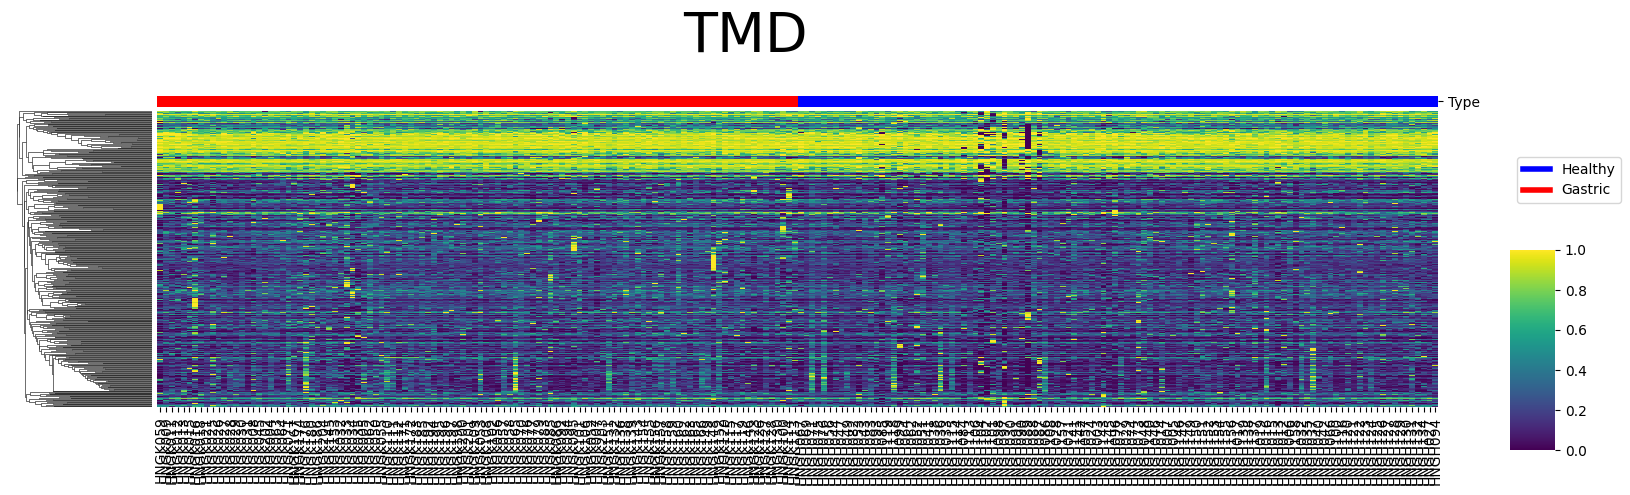

In [384]:
heatmapfea('TMD')

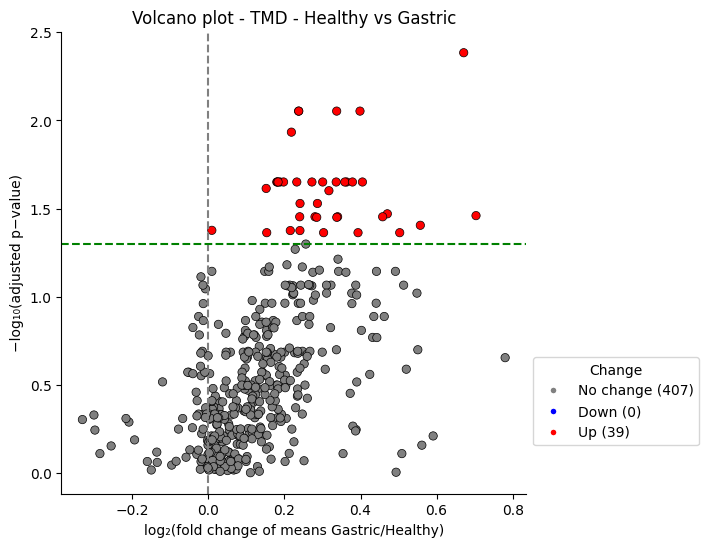

In [385]:
volcanofea('TMD',pair=['Healthy vs Gastric'],
show_region=True
)

In [386]:
f='TMD'
top=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<0.05].sort_values(by='Log2FC of '+p).reset_index(drop=True)['FEATURES'][0:5])+list(stats_fea[f][stats_fea[f]['PADJ of '+p]<0.05].sort_values(by='Log2FC of '+p,ascending=False).reset_index(drop=True)['FEATURES'][0:5])
plot1=fea[f][['Class']+top[0:1]].melt(id_vars="Class")
plot1['x']=plot1.apply(lambda r: r['variable'][4:]+'_'+str(r['Class']),axis=1)
plot1.sort_values(by='x',inplace=True)
em_lst=list(plot1['variable'].unique())
plot2=fea[f][['Class']+top[len(em_lst)-6:]].melt(id_vars="Class")

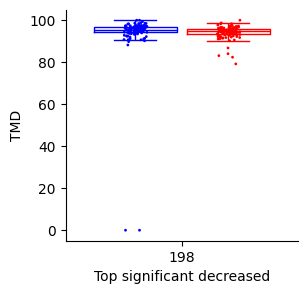

In [387]:
plt.figure(figsize=(3,3))
sb.boxplot(data=plot1,y='value',x='variable',hue='Class',
           palette=['b','r'],hue_order=[0,4],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=plot1,y='value',x='variable',hue='Class',
             palette=['b','r'],hue_order=[0,4],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
plt.yticks(np.arange(0,110,20))
# em_lst=list(plot1['variable'].unique())
plt.xticks(ticks=list(range(0,len(em_lst))),labels=[em.split('_')[1] for em in em_lst])
plt.ylabel('TMD')
plt.xlabel('Top significant decreased')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p-value < 0.00001','Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.3, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.05, .1),loc='center right',frameon=False)

# plt.text(x=0,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=1,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=2,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=3,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=4,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.007,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_1.png',dpi=600,bbox_inches='tight')


In [388]:
list(plot2['variable'].unique())

['TMD_407', 'TMD_91', 'TMD_138', 'TMD_137', 'TMD_49']

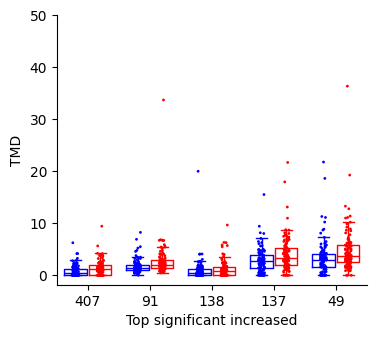

In [389]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=plot2,y='value',x='variable',hue='Class',
           palette=['b','r'],hue_order=[0,4],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=plot2,y='value',x='variable',hue='Class',
             palette=['b','r'],hue_order=[0,4],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
plt.yticks(np.arange(0,60,10))
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(plot2['variable'].unique())])
plt.ylabel('TMD')
plt.xlabel('Top significant increased')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
# plt.text(x=0,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=1,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=2,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=3,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=4,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
# plt.text(x=-1.1,y=-0.0015,s='*****  p-value ')

# ENT

In [390]:
f='ENTTMEM'
# f='ENTTMFLEN'

In [391]:
EM_top=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<0.05].sort_values(by='Log2FC of '+p).reset_index(drop=True)['FEATURES'][0:5])+list(stats_fea[f][stats_fea[f]['PADJ of '+p]<0.05].sort_values(by='Log2FC of '+p,ascending=False).reset_index(drop=True)['FEATURES'][0:5])
EM_top

['ENTTMEM_3',
 'ENTTMEM_2',
 'ENTTMEM_1',
 'ENTTMEM_35',
 'ENTTMEM_38',
 'ENTTMEM_394',
 'ENTTMEM_54',
 'ENTTMEM_350',
 'ENTTMEM_177',
 'ENTTMEM_315']

In [392]:
EM_plot1=fea[f][['Class']+EM_top[0:5]].melt(id_vars="Class")
EM_plot1['x']=EM_plot1.apply(lambda r: r['variable'][4:]+'_'+str(r['Class']),axis=1)
EM_plot1.sort_values(by='x',inplace=True)
EM_plot1

,Class,variable,value,x
481,0.0,ENTTMEM_1,8.100092,MEM_1_0.0
494,0.0,ENTTMEM_1,7.078641,MEM_1_0.0
493,0.0,ENTTMEM_1,7.615703,MEM_1_0.0
492,0.0,ENTTMEM_1,7.851140,MEM_1_0.0
491,0.0,ENTTMEM_1,7.821752,MEM_1_0.0
...,...,...,...,...
114,4.0,ENTTMEM_3,7.640537,MEM_3_4.0
113,4.0,ENTTMEM_3,7.346845,MEM_3_4.0
112,4.0,ENTTMEM_3,7.936235,MEM_3_4.0
110,4.0,ENTTMEM_3,7.292352,MEM_3_4.0


In [393]:
EM_plot2=fea[f][['Class']+EM_top[5:10]].melt(id_vars="Class")
EM_plot2

,Class,variable,value
0,4.0,ENTTMEM_394,1.098612
1,4.0,ENTTMEM_394,1.386294
2,4.0,ENTTMEM_394,0.000000
3,4.0,ENTTMEM_394,1.386294
4,4.0,ENTTMEM_394,0.693147
...,...,...,...
1095,4.0,ENTTMEM_315,1.889159
1096,4.0,ENTTMEM_315,2.670120
1097,4.0,ENTTMEM_315,2.163956
1098,4.0,ENTTMEM_315,2.664619


In [394]:
list(EM_plot1['variable'].unique())

['ENTTMEM_1', 'ENTTMEM_2', 'ENTTMEM_35', 'ENTTMEM_38', 'ENTTMEM_3']

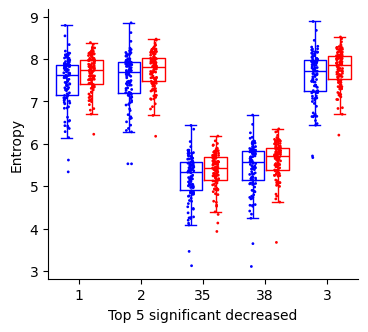

In [395]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot1,y='value',x='variable',hue='Class',
           palette=['b','r'],hue_order=[0,4],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot1,y='value',x='variable',hue='Class',
             palette=['b','r'],hue_order=[0,4],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
# plt.yticks(np.arange(0,0.012,0.002))
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(EM_plot1['variable'].unique())])
plt.ylabel('Entropy')
plt.xlabel('Top 5 significant decreased')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p-value < 0.00001','Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.3, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.05, .1),loc='center right',frameon=False)

# plt.text(x=0,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=1,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=2,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=3,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=4,y=0.0095,s='*****',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.007,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_1.png',dpi=600,bbox_inches='tight')

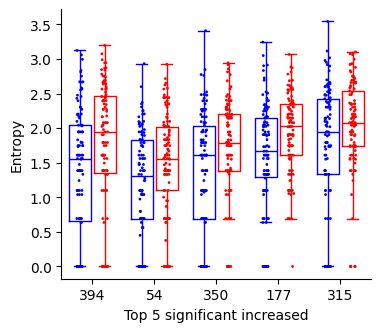

In [396]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot2,y='value',x='variable',hue='Class',
           palette=['b','r'],hue_order=[0,4],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot2,y='value',x='variable',hue='Class',
             palette=['b','r'],hue_order=[0,4],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
# plt.yticks(np.arange(0,0.0035,0.0005))
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(EM_plot2['variable'].unique())])
plt.ylabel('Entropy')
plt.xlabel('Top 5 significant increased')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
# plt.text(x=0,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=1,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=2,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=3,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=4,y=0.00285,s='*****',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
# plt.text(x=-1.1,y=-0.0015,s='*****  p-value ')

# Venn

In [397]:
set0=stats_fea['TMD'][stats_fea['TMD']['PADJ of Healthy vs Gastric']<0.05]
set0=set(set0['FEATURES'].str.split('_').str[1])
print(len(set0))
set0

39


{'107',
 '130',
 '137',
 '138',
 '143',
 '183',
 '190',
 '198',
 '207',
 '223',
 '226',
 '228',
 '23',
 '245',
 '247',
 '256',
 '257',
 '313',
 '319',
 '325',
 '329',
 '335',
 '364',
 '367',
 '369',
 '373',
 '377',
 '38',
 '393',
 '407',
 '434',
 '445',
 '49',
 '57',
 '60',
 '62',
 '63',
 '88',
 '91'}

In [398]:
set1=stats_fea['TMCNA'][stats_fea['TMCNA']['PADJ of Healthy vs Gastric']<0.05]
set1=set(set1['FEATURES'].str.split('_').str[1])
print(len(set1))
set1

235


{'1',
 '10',
 '101',
 '102',
 '106',
 '11',
 '110',
 '111',
 '114',
 '115',
 '116',
 '119',
 '12',
 '121',
 '122',
 '124',
 '125',
 '129',
 '134',
 '135',
 '136',
 '14',
 '140',
 '142',
 '144',
 '146',
 '147',
 '15',
 '150',
 '151',
 '152',
 '153',
 '154',
 '157',
 '16',
 '160',
 '161',
 '163',
 '164',
 '166',
 '167',
 '169',
 '170',
 '171',
 '172',
 '173',
 '174',
 '175',
 '176',
 '177',
 '178',
 '180',
 '181',
 '182',
 '185',
 '187',
 '190',
 '191',
 '192',
 '193',
 '194',
 '195',
 '197',
 '199',
 '2',
 '200',
 '201',
 '203',
 '205',
 '206',
 '207',
 '209',
 '21',
 '210',
 '211',
 '212',
 '216',
 '218',
 '22',
 '223',
 '225',
 '227',
 '228',
 '23',
 '230',
 '234',
 '235',
 '236',
 '237',
 '239',
 '24',
 '240',
 '242',
 '243',
 '244',
 '245',
 '247',
 '249',
 '25',
 '251',
 '253',
 '254',
 '255',
 '256',
 '259',
 '26',
 '261',
 '262',
 '263',
 '264',
 '265',
 '266',
 '267',
 '269',
 '27',
 '270',
 '271',
 '272',
 '274',
 '275',
 '276',
 '277',
 '278',
 '279',
 '28',
 '280',
 '281',
 '

In [399]:
set2=stats_fea['ENTTMEM'][stats_fea['ENTTMEM']['PADJ of Healthy vs Gastric']<0.05]
set2=set(set2['FEATURES'].str.split('_').str[1])
print(len(set2))
set2

196


{'1',
 '108',
 '109',
 '11',
 '111',
 '115',
 '116',
 '117',
 '118',
 '126',
 '13',
 '134',
 '136',
 '138',
 '139',
 '14',
 '140',
 '144',
 '146',
 '147',
 '149',
 '15',
 '150',
 '151',
 '152',
 '157',
 '158',
 '16',
 '163',
 '164',
 '166',
 '168',
 '169',
 '17',
 '170',
 '171',
 '176',
 '177',
 '183',
 '185',
 '186',
 '187',
 '19',
 '191',
 '192',
 '193',
 '196',
 '199',
 '2',
 '200',
 '203',
 '205',
 '208',
 '21',
 '210',
 '211',
 '213',
 '214',
 '215',
 '216',
 '218',
 '22',
 '220',
 '222',
 '224',
 '227',
 '228',
 '229',
 '23',
 '230',
 '232',
 '233',
 '234',
 '237',
 '244',
 '246',
 '249',
 '25',
 '250',
 '254',
 '255',
 '259',
 '260',
 '266',
 '267',
 '271',
 '275',
 '276',
 '28',
 '281',
 '282',
 '283',
 '285',
 '286',
 '287',
 '288',
 '292',
 '293',
 '297',
 '298',
 '3',
 '30',
 '300',
 '301',
 '302',
 '305',
 '306',
 '309',
 '31',
 '313',
 '314',
 '315',
 '317',
 '319',
 '320',
 '324',
 '330',
 '333',
 '336',
 '34',
 '341',
 '342',
 '343',
 '344',
 '348',
 '35',
 '350',
 '352'

In [400]:
set3=stats_fea['ENTTMFLEN'][stats_fea['ENTTMFLEN']['PADJ of Healthy vs Gastric']<0.05]
set3=set(set3['FEATURES'].str.split('_').str[1])
print(len(set3))
set3

53


{'111',
 '115',
 '117',
 '136',
 '139',
 '140',
 '144',
 '176',
 '177',
 '185',
 '186',
 '192',
 '218',
 '227',
 '230',
 '233',
 '249',
 '266',
 '271',
 '281',
 '285',
 '301',
 '302',
 '315',
 '320',
 '329',
 '333',
 '343',
 '344',
 '371',
 '372',
 '373',
 '376',
 '390',
 '394',
 '411',
 '416',
 '420',
 '422',
 '435',
 '444',
 '447',
 '450',
 '46',
 '47',
 '54',
 '55',
 '65',
 '71',
 '82',
 '84',
 '88',
 '92'}

In [401]:
from matplotlib_venn import venn3_unweighted

c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


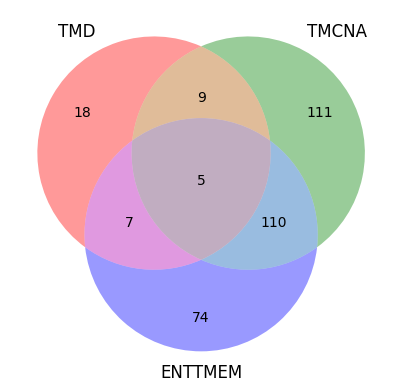

In [402]:
plt.figure()

venn3_unweighted(
    subsets=(set0, set1, set2),
    set_labels=('TMD', 'TMCNA', 'ENTTMEM')
)

plt.show()

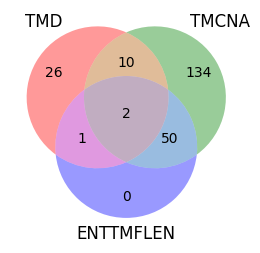

In [403]:
plt.figure(figsize=(3,3))
matplotlib_venn.venn3_unweighted([set0,set2,set3],['TMD','TMCNA','ENTTMFLEN'])

In [404]:
c=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\TMD_feature_name.csv")
c

,chrom,feature_name,CHR,start,end,gene,location,region code
0,chr1,TMD_1,1,1163599,1163832,C1orf159_TTLL10,1:1163599-1163832,1
1,chr1,TMD_2,1,2443865,2444245,PEX10_PLCH2,1:2443865-2444245,2
2,chr1,TMD_3,1,2789325,2789609,ACTRT2_MMEL1,1:2789325-2789609,3
3,chr1,TMD_4,1,2789723,2790126,ACTRT2_MMEL1,1:2789723-2790126,4
4,chr1,TMD_5,1,6064999,6065249,KCNAB2_CHD5,1:6064999-6065249,5
...,...,...,...,...,...,...,...,...
445,chr22,TMD_286,22,27799853,27800150,MN1,22:27799853-27800150,286
446,chr22,TMD_287,22,46007845,46008261,PPARA_WNT7B,22:46007845-46008261,287
447,chr22,TMD_288,22,46525740,46525932,CELSR1_TRMU,22:46525740-46525932,288
448,chr22,TMD_289,22,50548840,50549077,TYMP_SYCE3,22:50548840-50549077,289


In [405]:
lst=list(set0&set1&set2)
lst1 = ["TMD_" + str(x) for x in lst]
lst1

['TMD_23', 'TMD_228', 'TMD_38', 'TMD_88', 'TMD_377']

In [406]:
df=c[c['feature_name'].isin(lst1)]
df

,chrom,feature_name,CHR,start,end,gene,location,region code
22,chr1,TMD_23,1,110083552,110083775,UBL4B_ALX3,1:110083552-110083775,23
37,chr1,TMD_38,1,220876745,220876918,HLX,1:220876745-220876918,38
55,chr2,TMD_228,2,45000612,45000891,SIX2_SIX3,2:45000612-45000891,228
181,chr7,TMD_377,7,351427,351579,PDGFA_FAM20C,7:351427-351579,377
300,chr11,TMD_88,11,62444331,62444643,SCGB1A1_AHNAK,11:62444331-62444643,88


In [407]:
lst=list(set0&set2&set3)
lst2 = ["TMD_" + str(x) for x in lst]
lst2

['TMD_88', 'TMD_373']

In [408]:
df=c[c['feature_name'].isin(lst2)]
df

,chrom,feature_name,CHR,start,end,gene,location,region code
179,chr6,TMD_373,6,163396939,163397210,PARK2_QKI,6:163396939-163397210,373
300,chr11,TMD_88,11,62444331,62444643,SCGB1A1_AHNAK,11:62444331-62444643,88


In [409]:
df.to_clipboard()

<Figure size 1000x1000 with 0 Axes>

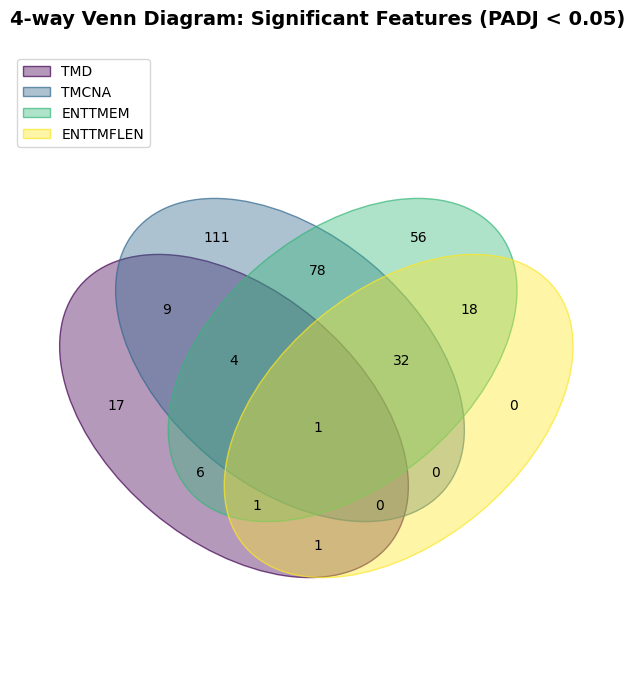

In [410]:
from venn import venn
import matplotlib.pyplot as plt

# 1. Tập hợp các set và nhãn vào một dictionary
# (Giả sử set0, set1, set2, set3 đã được bạn tạo ở bước trước)
data_venn = {
    'TMD': set0,
    'TMCNA': set1,
    'ENTTMEM': set2,
    'ENTTMFLEN': set3
}

# 2. Vẽ biểu đồ Venn cho 4 nhóm
# Thư viện venn sẽ tự động dùng hình bầu dục (ellipses) để hiển thị đủ 15 vùng giao nhau
plt.figure(figsize=(10, 10))
venn(data_venn, fmt="{size}", fontsize=10, legend_loc="upper left")

# 3. Tinh chỉnh tiêu đề
plt.title("4-way Venn Diagram: Significant Features (PADJ < 0.05)", 
          fontsize=14, fontweight='bold', pad=20)

plt.show()

In [411]:
lst=list(set0&set1&set2&set3)
lst3 = ["TMD_" + str(x) for x in lst]
lst3

df=c[c['feature_name'].isin(lst3)]
df

,chrom,feature_name,CHR,start,end,gene,location,region code
300,chr11,TMD_88,11,62444331,62444643,SCGB1A1_AHNAK,11:62444331-62444643,88


c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


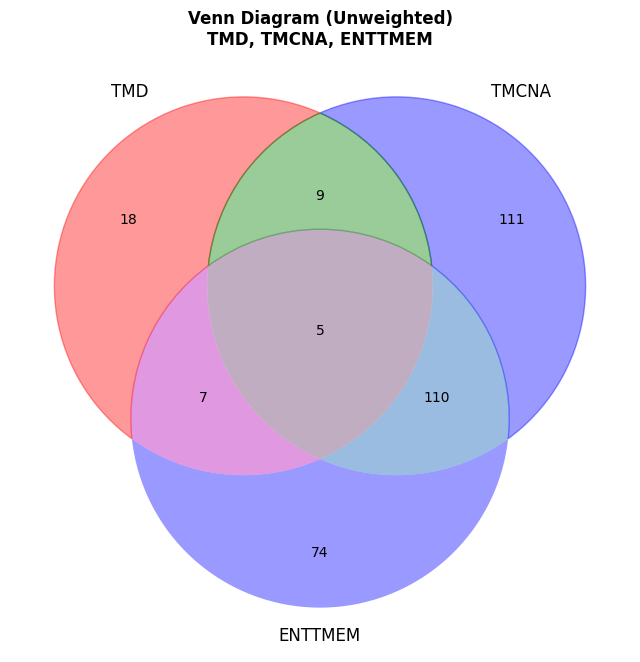

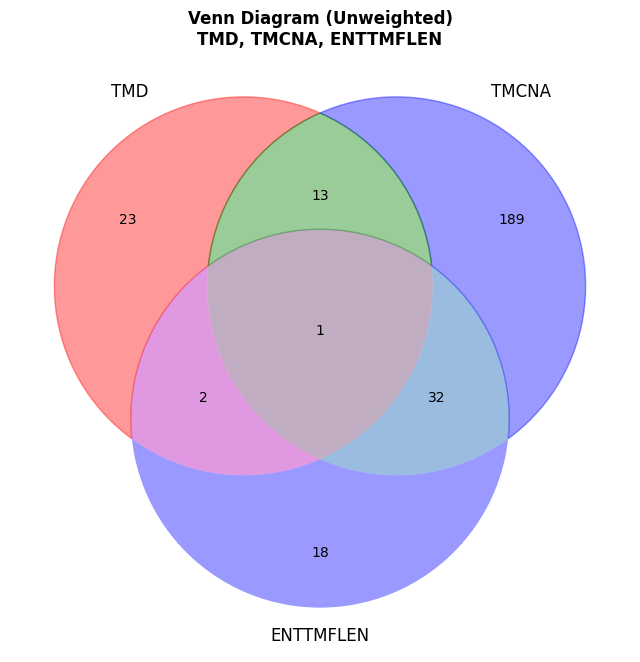

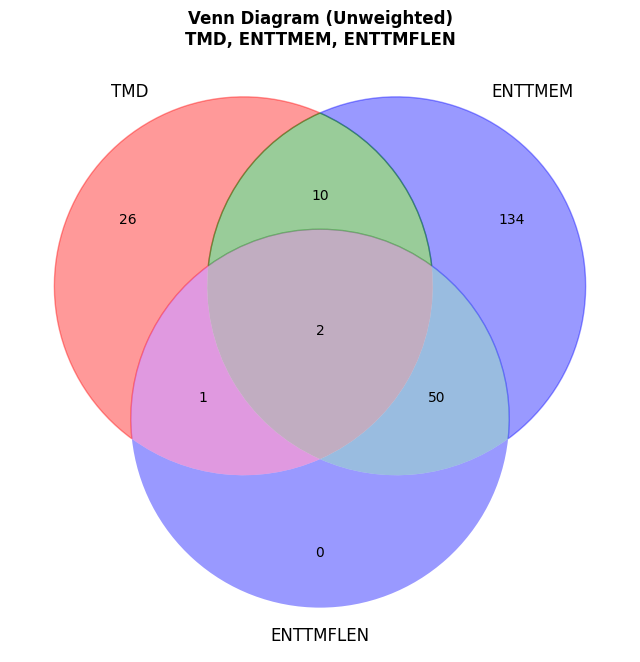

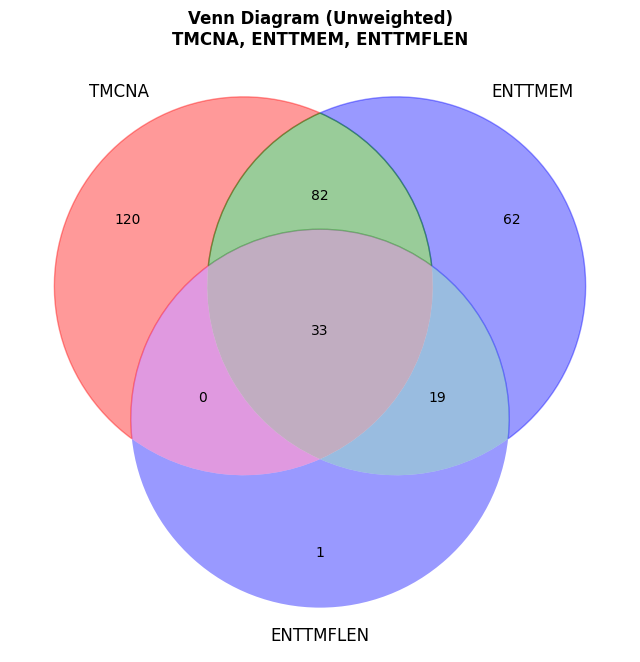

In [412]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3_unweighted
from itertools import combinations

# 1. Định nghĩa danh sách các set và nhãn tương ứng (từ code bạn đã cung cấp)
# Giả sử set0, set1, set2, set3 đã được bạn tạo từ trước
all_sets = [set0, set1, set2, set3]
all_labels = ['TMD', 'TMCNA', 'ENTTMEM', 'ENTTMFLEN']

# 2. Tạo danh sách các chỉ số (0, 1, 2, 3) để lấy tổ hợp 3
indices = range(len(all_sets))
comb_indices = list(combinations(indices, 3))

# 3. Vòng lặp vẽ đồ thị cho từng tổ hợp
for idx_tuple in comb_indices:
    # Lấy ra 3 set và 3 nhãn dựa trên tổ hợp chỉ số
    current_sets = [all_sets[i] for i in idx_tuple]
    current_labels = [all_labels[i] for i in idx_tuple]
    
    plt.figure(figsize=(8, 8))
    
    # Vẽ Venn unweighted
    v = venn3_unweighted(
        subsets=current_sets,
        set_labels=current_labels
    )
    
    # Tinh chỉnh giao diện
    plt.title(f"Venn Diagram (Unweighted)\n{', '.join(current_labels)}", 
              fontsize=12, fontweight='bold')
    
    # Thêm màu sắc để phân biệt rõ các vòng tròn
    if v:
        colors = ['red', 'blue', 'green']
        for i, patch in enumerate(v.patches[:3]): # 3 vùng chính
            if patch:
                patch.set_alpha(0.4)
                patch.set_color(colors[i])
    
    plt.show()

Đã đọc xong sheet TMCNA. Số lượng vùng dữ liệu: 450


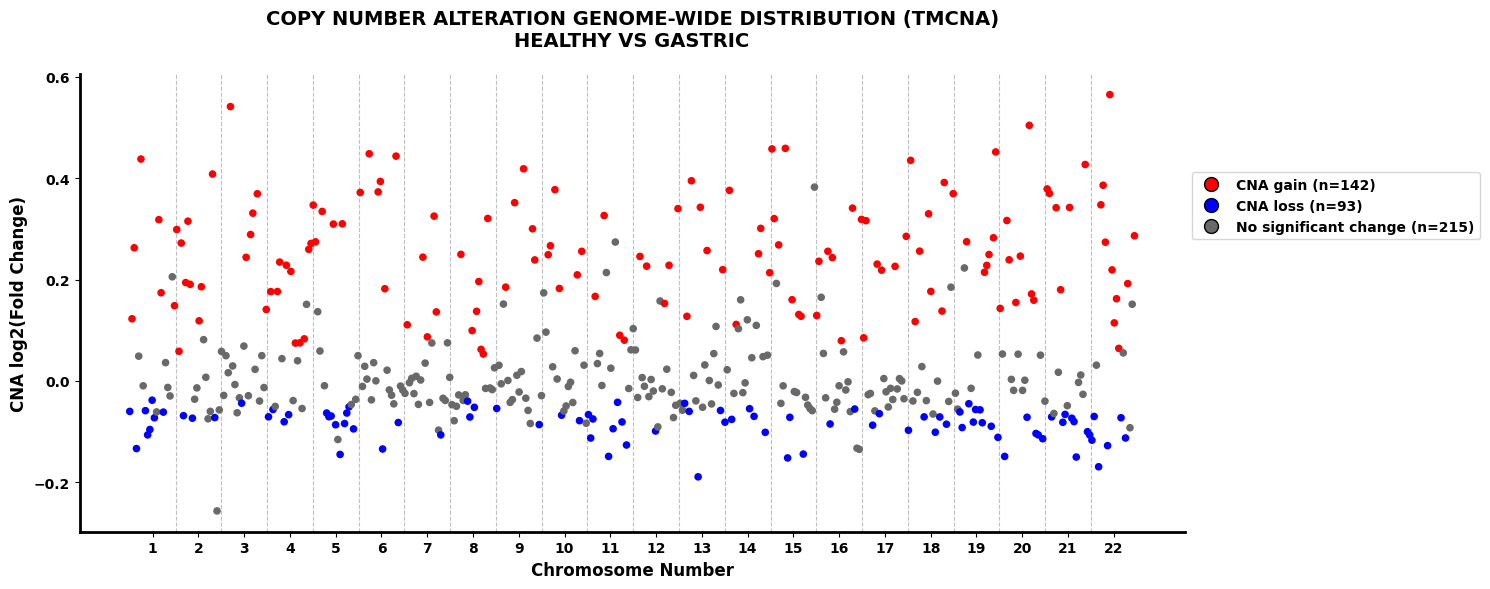

In [413]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 1. ĐỌC DỮ LIỆU TRỰC TIẾP TỪ EXCEL (Sheet TMCNA)
file_path = r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\HNG_STATS.xlsx"
sheet_name = 'TMCNA'

try:
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    print(f"Đã đọc xong sheet {sheet_name}. Số lượng vùng dữ liệu: {len(df)}")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}")

# 2. CẤU HÌNH CỘT VÀ NGƯỠNG THỐNG KÊ
pair_name = 'Healthy vs Gastric'
col_log = f'Log2FC of {pair_name}'
col_padj = f'PADJ of {pair_name}'
alpha = 0.05

# 3. TỰ ĐỘNG CHIA VỊ TRÍ 22 CHROMOSOME
total_bins = len(df)
vlines = np.linspace(0, total_bins, 23)[1:-1] 
positions = np.linspace(0, total_bins, 23)[:-1] + (total_bins/44)
xlabels = [str(i) for i in range(1, 23)]

# 4. LOGIC MÀU SẮC CHO CNA (Gain/Loss)
def get_colors(row):
    if row[col_padj] < alpha:
        if row[col_log] > 0: return 'red'    # CNA Gain
        if row[col_log] < 0: return 'blue'   # CNA Loss
    return 'dimgray' 

df['color'] = df.apply(get_colors, axis=1)

# 5. VẼ ĐỒ THỊ CNA
plt.figure(figsize=(15, 6))
ax = plt.gca()

# Vẽ đường phân cách NST
for v in vlines:
    plt.axvline(x=v, color='black', linestyle='--', linewidth=0.8, alpha=0.25)

# Vẽ dữ liệu Scatter
plt.scatter(range(len(df)), df[col_log], c=df['color'], s=20, alpha=1, zorder=3)

# 6. TÍNH TOÁN SỐ LƯỢNG N VÀ THIẾT KẾ LEGEND (Cập nhật nhãn Gain/Loss)
n_gain = len(df[df['color'] == 'red'])
n_loss = len(df[df['color'] == 'blue'])
n_no = len(df[df['color'] == 'dimgray'])

custom_lines = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, mec='black', mew=1),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, mec='black', mew=1),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dimgray', markersize=10, mec='black', mew=1)
]
legend_labels = [
    f'CNA gain (n={n_gain})', 
    f'CNA loss (n={n_loss})', 
    f'No significant change (n={n_no})'
]

leg = plt.legend(custom_lines, legend_labels, loc='upper left', bbox_to_anchor=(1, 0.8), 
                 frameon=True, prop={'weight': 'bold', 'size': 10})
leg.get_title().set_fontweight('bold')

# 7. ĐỊNH DẠNG TRỤC VÀ NHÃN (Làm đậm)
plt.xticks(ticks=positions, labels=xlabels, fontsize=10, fontweight='bold', color='black')
plt.yticks(fontweight='bold', color='black')
plt.xlabel('Chromosome Number', fontsize=12, fontweight='bold', color='black')
plt.ylabel('CNA log2(Fold Change)', fontsize=12, fontweight='bold', color='black')
plt.title(f'COPY NUMBER ALTERATION GENOME-WIDE DISTRIBUTION ({sheet_name})\n{pair_name.upper()}', 
          fontsize=14, fontweight='bold', color='black', pad=20)

# Làm đậm khung đồ thị
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)
    ax.spines[spine].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Đã đọc xong sheet ENTTMEM. Tổng số vùng: 450


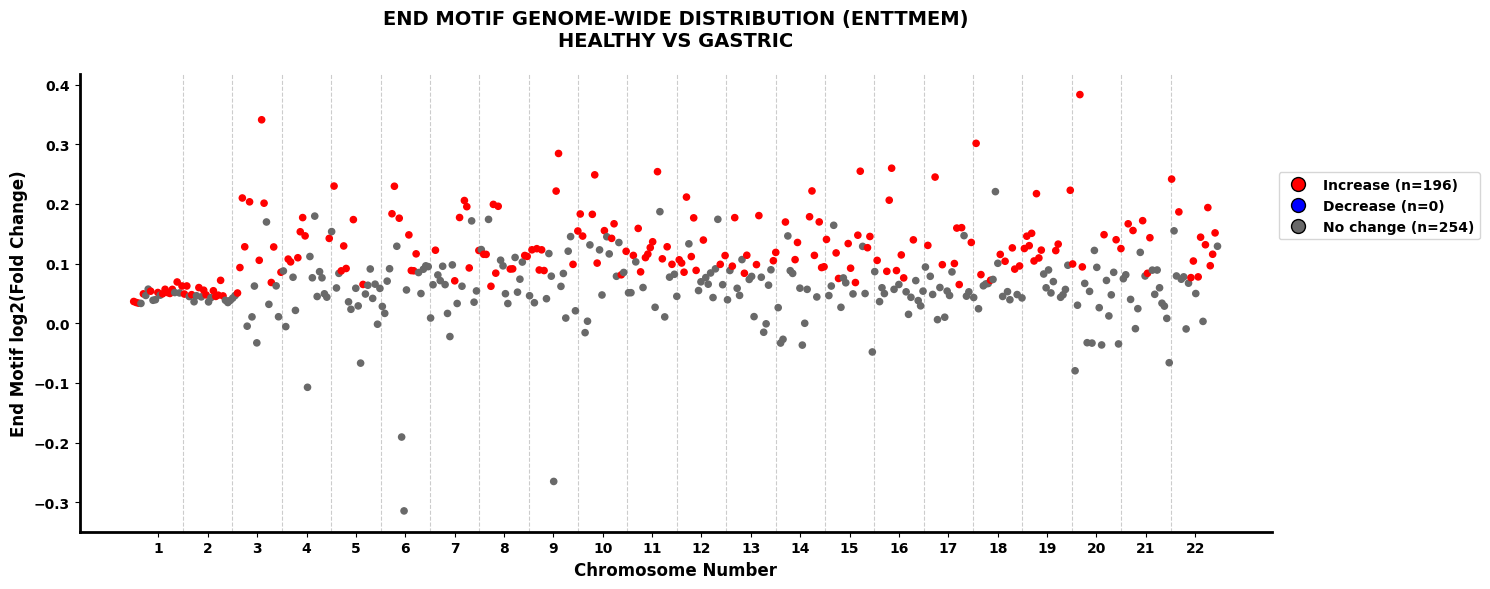

In [414]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 1. ĐỌC DỮ LIỆU TỪ EXCEL
file_path = r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\HNG_STATS.xlsx"
sheet_name = 'ENTTMEM'

try:
    # Sử dụng read_excel thay vì read_csv
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    print(f"Đã đọc xong sheet {sheet_name}. Tổng số vùng: {len(df)}")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}")
    # Nếu máy bạn thiếu thư viện openpyxl, hãy chạy lệnh: pip install openpyxl

# 2. CẤU HÌNH CỘT DỮ LIỆU
pair_name = 'Healthy vs Gastric'
col_log = f'Log2FC of {pair_name}'
col_padj = f'PADJ of {pair_name}'
alpha = 0.05

# 3. TỰ ĐỘNG XÁC ĐỊNH VỊ TRÍ CHROMOSOME (Dựa trên index vùng)
# Giả sử có 448 vùng chia cho 22 Chromosome
total_bins = len(df)
vlines = np.linspace(0, total_bins, 23)[1:-1] # Tạo 21 đường kẻ phân cách cho 22 Chromosome
positions = np.linspace(0, total_bins, 23)[:-1] + (total_bins/44)
xlabels = [str(i) for i in range(1, 23)]

# 4. ĐỊNH NGHĨA MÀU SẮC ĐẬM
def get_colors(row):
    if row[col_padj] < alpha:
        if row[col_log] > 0: return 'red'   # Tăng
        if row[col_log] < 0: return 'blue'  # Giảm
    return 'dimgray' # Không ý nghĩa

df['color'] = df.apply(get_colors, axis=1)

# 5. VẼ ĐỒ THỊ
plt.figure(figsize=(15, 6))
ax = plt.gca()

# Vẽ đường phân cách Chromosome
for v in vlines:
    plt.axvline(x=v, color='black', linestyle='--', linewidth=0.8, alpha=0.2)

# Vẽ các điểm dữ liệu (Làm đậm)
plt.scatter(range(len(df)), df[col_log], c=df['color'], s=20, alpha=1, zorder=3)

# 6. TÍNH TOÁN N VÀ CHÚ THÍCH (LEGEND)
n_up = len(df[df['color'] == 'red'])
n_down = len(df[df['color'] == 'blue'])
n_no = len(df[df['color'] == 'dimgray'])

custom_lines = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, mec='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, mec='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dimgray', markersize=10, mec='black')
]
legend_labels = [f'Increase (n={n_up})', f'Decrease (n={n_down})', f'No change (n={n_no})']

leg = plt.legend(custom_lines, legend_labels, loc='upper left', bbox_to_anchor=(1, 0.8), 
                 frameon=True, prop={'weight': 'bold'})
leg.get_title().set_fontweight('bold')

# 7. ĐỊNH DẠNG TRỤC (IN ĐẬM)
plt.xticks(ticks=positions, labels=xlabels, fontsize=10, fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlabel('Chromosome Number', fontsize=12, fontweight='bold')
plt.ylabel('End Motif log2(Fold Change)', fontsize=12, fontweight='bold')
plt.title(f'END MOTIF GENOME-WIDE DISTRIBUTION ({sheet_name})\n{pair_name.upper()}', 
          fontsize=14, fontweight='bold', pad=20)

# Làm đậm khung hình
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Đã đọc xong sheet ENTTMFLEN. Số lượng vùng dữ liệu: 450


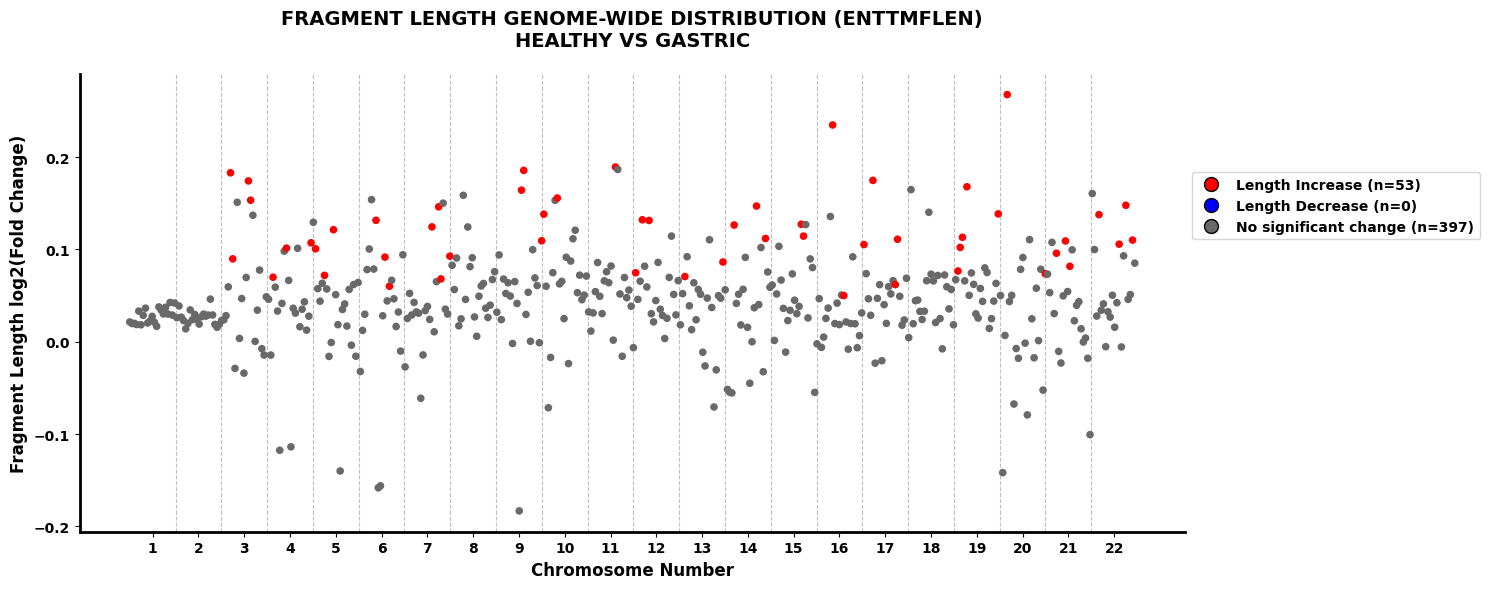

In [415]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 1. ĐỌC DỮ LIỆU TRỰC TIẾP TỪ EXCEL
file_path = r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\450 Region\HNG_STATS.xlsx"
sheet_name = 'ENTTMFLEN'

try:
    # Đọc dữ liệu từ sheet Fragment Length
    df = pd.read_excel(file_path, sheet_name=sheet_name)
    print(f"Đã đọc xong sheet {sheet_name}. Số lượng vùng dữ liệu: {len(df)}")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}. Vui lòng kiểm tra lại đường dẫn file.")

# 2. CẤU HÌNH CỘT VÀ NGƯỠNG THỐNG KÊ
pair_name = 'Healthy vs Gastric'
col_log = f'Log2FC of {pair_name}'
col_padj = f'PADJ of {pair_name}'
alpha = 0.05

# 3. TỰ ĐỘNG CHIA VỊ TRÍ 22 CHROMOSOME
total_bins = len(df)
# Tạo 21 đường kẻ phân cách để chia làm 22 phần
vlines = np.linspace(0, total_bins, 23)[1:-1] 
# Tính toán vị trí trung tâm của mỗi nhóm để đặt nhãn số Chromosome
positions = np.linspace(0, total_bins, 23)[:-1] + (total_bins/44)
xlabels = [str(i) for i in range(1, 23)]

# 4. LOGIC MÀU SẮC ĐẬM (Dựa trên Padj và Log2FC)
def get_colors(row):
    if row[col_padj] < alpha:
        if row[col_log] > 0: return 'red'    # Fragment Length tăng (dài hơn)
        if row[col_log] < 0: return 'blue'   # Fragment Length giảm (ngắn hơn)
    return 'dimgray' # Không có ý nghĩa thống kê

df['color'] = df.apply(get_colors, axis=1)

# 5. VẼ ĐỒ THỊ FRAGMENT LENGTH
plt.figure(figsize=(15, 6))
ax = plt.gca()

# Vẽ đường phân cách Chromosome (nét đứt, đậm hơn một chút để rõ ràng)
for v in vlines:
    plt.axvline(x=v, color='black', linestyle='--', linewidth=0.8, alpha=0.25)

# Vẽ dữ liệu (Scatter plot) với độ đậm cao nhất
plt.scatter(range(len(df)), df[col_log], c=df['color'], s=20, alpha=1, zorder=3)

# 6. TÍNH TOÁN SỐ LƯỢNG N VÀ THIẾT KÊ LEGEND
n_up = len(df[df['color'] == 'red'])
n_down = len(df[df['color'] == 'blue'])
n_no = len(df[df['color'] == 'dimgray'])

custom_lines = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, mec='black', mew=1),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, mec='black', mew=1),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='dimgray', markersize=10, mec='black', mew=1)
]
legend_labels = [
    f'Length Increase (n={n_up})', 
    f'Length Decrease (n={n_down})', 
    f'No significant change (n={n_no})'
]

leg = plt.legend(custom_lines, legend_labels, loc='upper left', bbox_to_anchor=(1, 0.8), 
                 frameon=True,  prop={'weight': 'bold', 'size': 10})
leg.get_title().set_fontweight('bold')

# 7. ĐỊNH DẠNG TRỤC VÀ NHÃN (IN ĐẬM TOÀN BỘ)
plt.xticks(ticks=positions, labels=xlabels, fontsize=10, fontweight='bold', color='black')
plt.yticks(fontweight='bold', color='black')
plt.xlabel('Chromosome Number', fontsize=12, fontweight='bold', color='black')
plt.ylabel('Fragment Length log2(Fold Change)', fontsize=12, fontweight='bold', color='black')
plt.title(f'FRAGMENT LENGTH GENOME-WIDE DISTRIBUTION ({sheet_name})\n{pair_name.upper()}', 
          fontsize=14, fontweight='bold', color='black', pad=20)

# Làm đậm khung đồ thị (Border)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)
    ax.spines[spine].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [419]:
import pandas as pd

# 1. Lấy dữ liệu và trích xuất danh sách gene
target_df = stats_fea['TMD'] 
set0_df = target_df[target_df['PADJ of Healthy vs Gastric'] < 0.05]
gene_list = sorted(list(set(set0_df['FEATURES'].str.split('_').str[1])))

# 2. Tạo một DataFrame để ép Jupyter hiển thị dạng bảng dọc
df_display = pd.DataFrame({
    'STT': range(1, len(gene_list) + 1),
    'Gene Name': gene_list
})

# 3. Cấu hình để hiển thị tối đa 50 dòng (không bị dấu ...)
pd.set_option('display.max_rows', 50)

# 4. Hiển thị
print(f"Tổng số gene tìm thấy: {len(gene_list)}")
print("-" * 40)
display(df_display) # Sử dụng display thay vì print để hiện bảng đẹp

Tổng số gene tìm thấy: 39
----------------------------------------


,STT,Gene Name
0,1,107
1,2,130
2,3,137
3,4,138
4,5,143
5,6,183
6,7,190
7,8,198
8,9,207
9,10,223


In [4]:
from gprofiler import GProfiler
import pandas as pd

# 1. Khởi tạo đối tượng GProfiler
gp = GProfiler()

# 2. Danh sách 39 gene của bạn (set0)
# Thay thế danh sách dưới đây bằng biến gene_list thực tế của bạn
genes = ["WNT1", "SEPT9", "ALX4"] # ... bổ sung đủ 39 gene vào đây

# 3. Thực hiện phân tích với TẤT CẢ các nguồn dữ liệu như trong hình
raw_results = gp.profile(
    organism='hsapiens',
    query=genes,
    # Bổ sung đầy đủ các nguồn: GO, Biological Pathways, Regulatory motifs, v.v.
    sources=[
        'GO:MF', 'GO:BP', 'GO:CC', # Gene Ontology
        'KEGG', 'REAC', 'WP',      # Biological pathways (Reactome, WikiPathways)
        'TF', 'MIRNA',             # Regulatory motifs (Transcription factors, miRNA)
        'HPA', 'CORUM', 'HP'       # Phenotypes & Protein complexes
    ],
    user_threshold=0.05,
    significance_threshold_method='fdr'
)

# 4. Xử lý hiển thị để không bị ngắt quãng và đầy đủ thông tin
if raw_results:
    # Chuyển đổi sang DataFrame
    results_df = pd.DataFrame(raw_results)
    
    # Cấu hình hiển thị của Pandas để không bị dấu "..."
    pd.set_option('display.max_rows', 100)
    pd.set_option('display.max_colwidth', None)
    
    # Chọn các cột quan trọng tương ứng với bảng kết quả trong hình
    # native: Term ID, name: Term Name, p_value: Padj
    cols_to_show = ['source', 'native', 'name', 'p_value', 'term_size', 'intersection_size']
    
    # Lọc các cột hiện có
    existing_cols = [c for c in cols_to_show if c in results_df.columns]
    
    print(f"Tổng số kết quả làm giàu tìm thấy: {len(results_df)}")
    print("-" * 50)
    
    # Hiển thị bảng kết quả
    display(results_df[existing_cols].sort_values(['source', 'p_value']))
else:
    print("Không tìm thấy kết quả nào có ý nghĩa thống kê với ngưỡng P < 0.05.")

Tổng số kết quả làm giàu tìm thấy: 214
--------------------------------------------------


,source,native,name,p_value,term_size,intersection_size
0,CORUM,CORUM:1345,Septin complex,0.002956,5,1
1,GO:BP,GO:0022004,midbrain-hindbrain boundary maturation during brain development,0.011301,1,1
2,GO:BP,GO:0021732,midbrain-hindbrain boundary maturation,0.011301,1,1
3,GO:BP,GO:0021576,hindbrain formation,0.011301,1,1
4,GO:BP,GO:0120034,positive regulation of plasma membrane bounded cell projection assembly,0.011301,111,2
...,...,...,...,...,...,...
114,WP,WP:WP428,Wnt signaling,0.037636,113,1
124,WP,WP:WP236,Adipogenesis,0.039552,130,1
132,WP,WP:WP2858,Ectoderm differentiation,0.041008,141,1
176,WP,WP:WP4262,Breast cancer pathway,0.042891,154,1


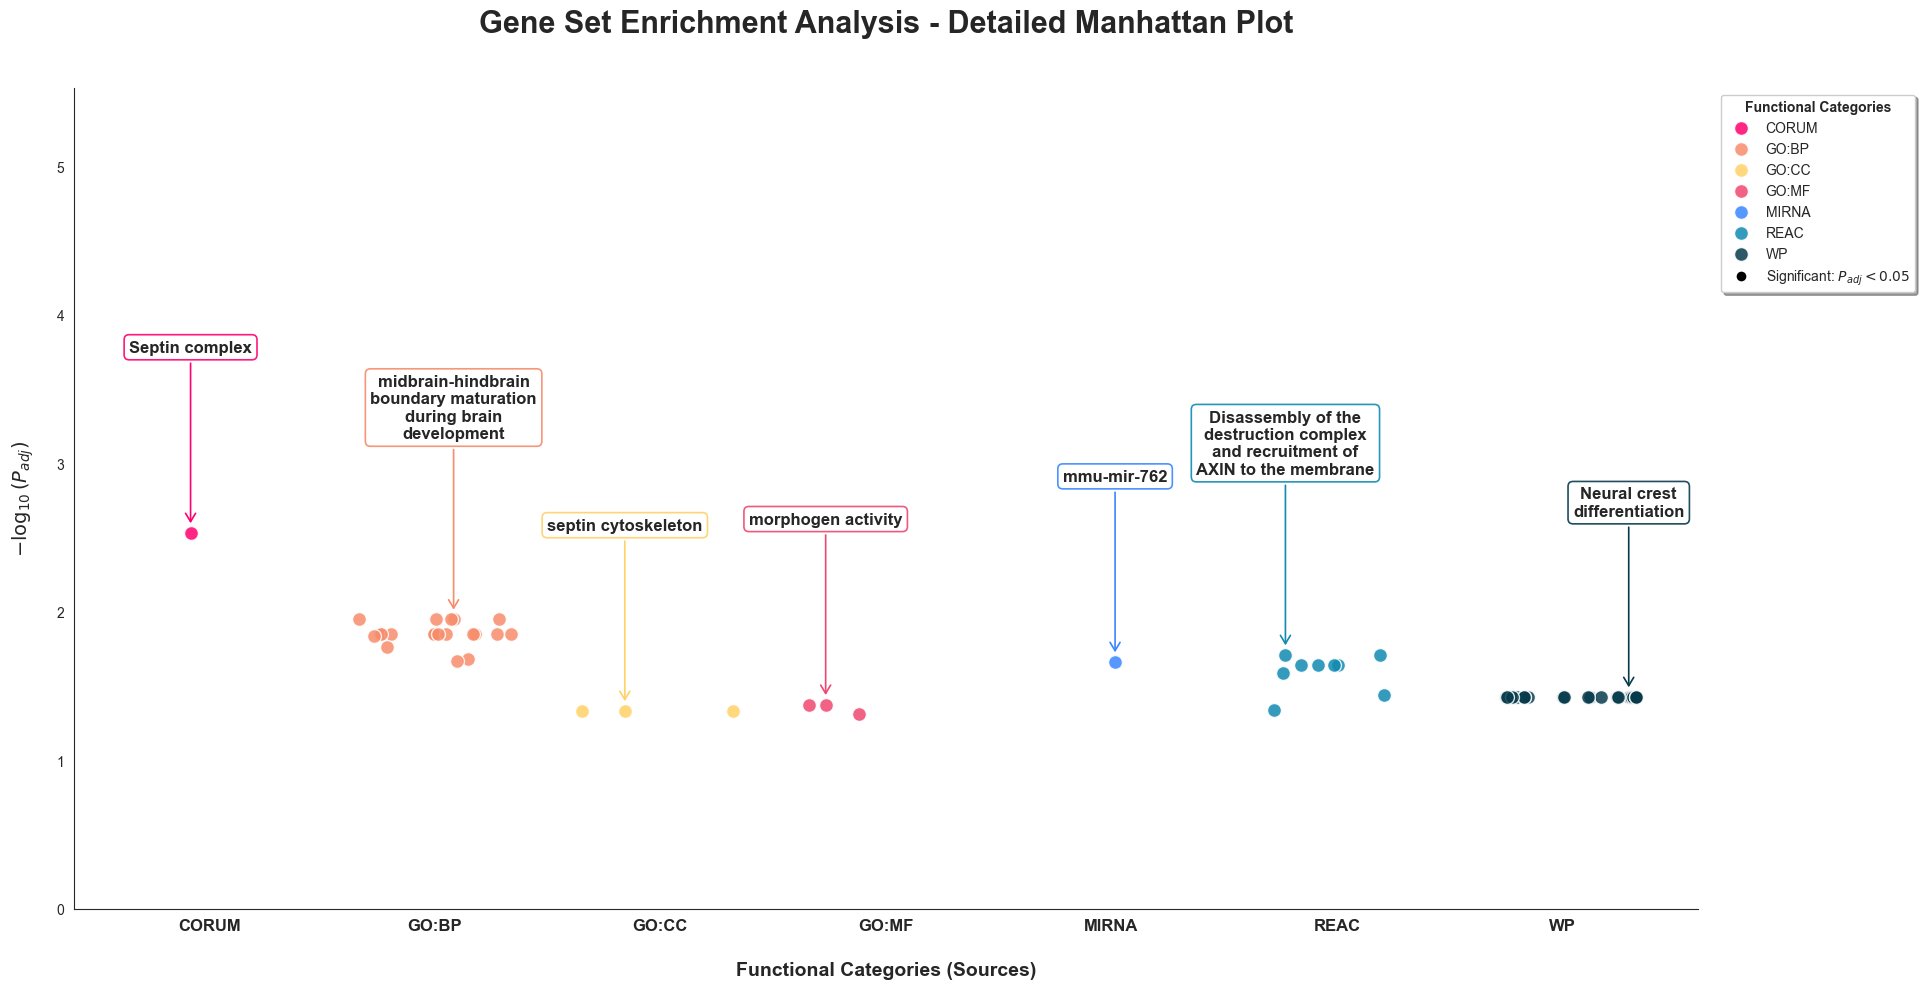

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import textwrap

def plot_deoverlapped_manhattan(results_df):
    if results_df is None or results_df.empty:
        print("Không có dữ liệu.")
        return

    # 1. Tiền xử lý dữ liệu
    df = results_df.copy()
    df['log_p'] = -np.log10(df['p_value'])
    df = df.sort_values(['source', 'p_value']).groupby('source').head(20).reset_index(drop=True)
    
    # Định nghĩa thứ tự nguồn
    unique_sources = sorted(df['source'].unique())
    df['source_idx'] = pd.Categorical(df['source'], categories=unique_sources).codes
    
    # Tăng Jitter (độ phân tán ngang) từ 0.2 lên 0.35 để các điểm tách nhau ra
    df['x_jitter'] = df['source_idx'] + np.random.uniform(-0.35, 0.35, size=len(df))

    # 2. Bảng màu
    colors_dict = {
        'GO:MF': '#EF476F', 'GO:BP': '#F78C6B', 'GO:CC': '#FFD166',
        'KEGG': '#06D6A0', 'REAC': '#118AB2', 'WP': '#073B4C',
        'TF': '#8338EC', 'MIRNA': '#3A86FF', 'HPA': '#FB5607',
        'CORUM': '#FF006E', 'HP': '#38B000'
    }

    # 3. Khởi tạo đồ thị với tỷ lệ khung hình rộng hơn
    fig, ax = plt.subplots(figsize=(22, 10)) # Tăng chiều rộng
    sns.set_style("white")

    # Vẽ các điểm dữ liệu - Giảm size từ 150 xuống 100 để giảm chồng lấn
    for source in unique_sources:
        data = df[df['source'] == source]
        ax.scatter(data['x_jitter'], data['log_p'], 
                   label=source, 
                   s=100,             # Giảm kích thước điểm giúp tách biệt
                   alpha=0.85, 
                   edgecolors='white', # Viền trắng giúp phân biệt các điểm chồng nhẹ
                   linewidth=1.0,      # Tăng độ dày viền
                   color=colors_dict.get(source, '#808080'), 
                   zorder=3)

    # 4. CHÚ GIẢI ĐIỂM (Annotate)
    for source in df['source'].unique():
        source_data = df[df['source'] == source]
        if not source_data.empty:
            top_node = source_data.loc[source_data['log_p'].idxmax()]
            wrapped_name = "\n".join(textwrap.wrap(top_node['name'], width=22))
            
            ax.annotate(wrapped_name,
                        xy=(top_node['x_jitter'], top_node['log_p']),
                        xytext=(top_node['x_jitter'], top_node['log_p'] + 1.2), # Giảm khoảng cách dọc
                        textcoords='data',
                        ha='center', va='bottom',
                        fontsize= 12, fontweight='bold',
                        arrowprops=dict(
                            arrowstyle='->, head_width=0.3, head_length=0.5', 
                            connectionstyle="arc3,rad=0", 
                            color=colors_dict.get(source), 
                            lw=1.2,
                            shrinkB=7 # Tăng khoảng cách đầu mũi tên với điểm
                        ),
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9, 
                                  ec=colors_dict.get(source), lw=1.2),
                        zorder=5)

    # 5. Định dạng các trục
    ax.set_xticks(range(len(unique_sources)))
    ax.set_xticklabels(unique_sources, rotation=0, fontsize=12, fontweight='bold')
    
    # Giới hạn trục X rộng hơn để các nhóm biên không bị sát lề
    ax.set_xlim(-0.6, len(unique_sources) - 0.4)
    
    ax.set_xlabel('Functional Categories (Sources)', fontsize=14, fontweight='bold', labelpad=20)
    ax.set_ylabel('$-\log_{10}(P_{adj})$', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_title('Gene Set Enrichment Analysis - Detailed Manhattan Plot', 
                 fontsize=22, pad=40, fontweight='bold')

    # 6. Chú thích bên phải
    handles, labels = ax.get_legend_handles_labels()
    p_info = Line2D([0], [0], marker='o', color='w', label='Significant: $P_{adj} < 0.05$',
                    markerfacecolor='black', markersize=8)
    handles.append(p_info)
    
    leg = ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1, 
                    frameon=True, shadow=True, title="Functional Categories", fontsize=10)
    leg.get_title().set_fontweight('bold')

    # 7. Tinh chỉnh không gian
    ax.set_ylim(0, df['log_p'].max() + 3.0) # Điều chỉnh trần trục Y vừa vặn hơn
    sns.despine()
    
    plt.tight_layout(rect=[0, 0, 0.88, 1]) 
    plt.show()

# Thực thi
plot_deoverlapped_manhattan(results_df)

Dựa trên các hình ảnh bạn cung cấp về kết quả phân tích làm giàu tập gene (Gene Set Enrichment Analysis), dưới đây là giải thích chi tiết về ý nghĩa sinh học của các thuật ngữ xuất hiện trong các hộp chú giải:

1. Septin complex (Phức hợp Septin)Nguồn dữ liệu: CORUM (Cơ sở dữ liệu về các phức hợp protein).Ý nghĩa sinh học: Các gene trong danh sách của bạn liên quan mật thiết đến việc hình thành Septin, một nhóm protein khung xương tế bào đặc biệt. Chúng đóng vai trò như một "giàn giáo" để tuyển dụng các protein khác, giúp phân chia tế bào, duy trì hình dạng tế bào và tạo ra các rào cản ngăn cách các vùng khác nhau trên màng tế bào.

2. Midbrain-hindbrain boundary maturation during brain development (Sự trưởng thành ranh giới não giữa - não sau trong quá trình phát triển não bộ)Nguồn dữ liệu: GO:BP (Biological Process - Quá trình sinh học).Ý nghĩa sinh học: Đây là một quá trình quan trọng trong giai đoạn phôi thai. Danh sách gene của bạn tham gia vào việc thiết lập và duy trì ranh giới giữa não giữa và não sau. Vùng ranh giới này hoạt động như một trung tâm điều khiển (organizer), tiết ra các tín hiệu để định hình và phân chia các vùng chức năng khác nhau của hệ thần kinh trung ương.

3. Septin cytoskeleton (Khung xương tế bào Septin)Nguồn dữ liệu: GO:CC (Cellular Component - Thành phần tế bào).Ý nghĩa sinh học: Thuật ngữ này chỉ rõ vị trí hoạt động của các sản phẩm gene. Nó khẳng định lại rằng các protein này là một phần cấu trúc của khung xương tế bào tại các vị trí như rãnh phân chia tế bào hoặc gốc của các sợi lông mao (cilia).

4. Morphogen activity (Hoạt tính hình thái học)Nguồn dữ liệu: GO:MF (Molecular Function - Chức năng phân tử).Ý nghĩa sinh học: Các gene của bạn mã hóa cho các Morphogen – các phân tử tín hiệu lan tỏa trong mô phôi. Tùy vào nồng độ nhận được, các tế bào sẽ được "ra lệnh" để biệt hóa thành các loại mô khác nhau, giúp hình thành nên hình dạng và cấu trúc phức tạp của các cơ quan.

5. mmu-mir-762Nguồn dữ liệu: MiRNA (Cơ sở dữ liệu về microRNA).Ý nghĩa sinh học: Điều này gợi ý rằng tập hợp gene của bạn có thể đang chịu sự điều hòa (thường là ức chế) bởi microRNA số 762. Đây là một cơ chế điều hòa sau phiên mã, cho thấy một sự thay đổi nhỏ của miRNA này có thể ảnh hưởng đồng loạt đến biểu hiện của nhiều gene trong danh sách của bạn.

6. Disassembly of the destruction complex and recruitment of AXIN to the membrane (Sự giải thể của phức hợp phá hủy và việc huy động AXIN đến màng tế bào)Nguồn dữ liệu: REAC (Reactome - Con đường sinh hóa chi tiết).Ý nghĩa sinh học: Đây là một bước then chốt trong con đường tín hiệu Wnt. Khi quá trình này xảy ra, nó ngăn chặn sự phân hủy protein $\beta$-catenin, cho phép protein này đi vào nhân tế bào để kích hoạt các gene liên quan đến sự tăng sinh và biệt hóa tế bào. Sự rối loạn ở bước này thường liên quan đến các khiếm khuyết bẩm sinh hoặc ung thư.

7. Neural crest differentiation (Sự biệt hóa mào thần kinh)Nguồn dữ liệu: WP (WikiPathways - Sơ đồ tương tác gene).Ý nghĩa sinh học: Mào thần kinh là một quần thể tế bào phôi thai có khả năng di cư cực mạnh và biệt hóa thành nhiều loại mô khác nhau như xương mặt, tế bào thần kinh, và tế bào sắc tố. 

Kết quả này cho thấy gene của bạn đóng vai trò quyết định trong việc chỉ đạo các tế bào mào thần kinh này trở thành loại tế bào trưởng thành nào.Tổng kết: Bức tranh sinh học từ các hộp chú giải này cho thấy danh sách gene của bạn tập trung rất mạnh vào quá trình phát triển phôi thai, đặc biệt là hệ thần kinh, thông qua việc điều khiển khung xương tế bào và các con đường tín hiệu (Wnt/Morphogen).